# Mixed-Effects Model v3: FWHM/LapVar Model Suite With Misalignment Comparison

Stroke lesion segmentation performance degrades with image quality. This notebook focuses the mixed-effects analysis on continuous image-quality predictors rather than categorical degradation-family indicators.

**Experimental design.** The model suite is trained on natural high-resolution images plus synthetic degradation variants from the high-resolution test subjects. A held-out natural low-resolution cohort is used for fixed-effect-only calibration. All mixed-effects models use a random intercept per subject.

**This copy's goal.** Compare nested FWHM, lesion-volume, LapVar, and misalignment specifications directly. The categorical degradation-family mixed models from the original v3 notebook are intentionally removed.


## Reference: Image Quality Metrics & Model Terms

### Image quality metrics (computed on each image individually)

| Metric | Full name | Units | Higher value = | Used in v2 notebook |
|---|---|---|---|---|
| `fwhm_mm` | Full Width at Half Maximum (FWHM) of the spatial autocorrelation | mm | **more blurry** (worse) | `z_mf_fwhm_mm` in the primary mixed model |
| `hi_freq_energy` | High-frequency energy fraction | unitless [0–1] | more high-freq power — in degraded images this often reflects **aliasing/ringing** rather than true sharpness | exploratory only in v2; removed from the primary mixed-model fixed effects |
| `lap_var` | Variance of the Laplacian | unitless | **sharper edges** (better) | `z_mf_lap_var` in the primary mixed model |

For this continuous model suite, FWHM and Laplacian variance are z-scored (mean = 0, SD = 1) across the training variants before model fitting, so their coefficients are directly comparable as Dice change per **1 standard deviation** shift. HFE is retained in the working dataframe for descriptive context only; it is excluded from the mixed-effects specifications.

### Outcome

| Term | Definition | Notes |
|---|---|---|
| `soft_dice` | Dice computed on raw predicted probabilities (no threshold) | Used as model outcome (logit-transformed) |
| `hard_dice_at_0.50` | Dice after binarising predictions at 0.50 | Nearly identical to soft Dice in this model; preferred for paper reporting |

### Model terms

| Term | Meaning |
|---|---|
| `misalign` | Binary flag (0/1): 1 = RigidJitter variant (slice misalignment artifact). Included only in the explicit misalignment-comparison models. |
| `(1 \| subject)` | Random intercept per subject — absorbs between-subject variability in baseline Dice (driven by lesion size, location, and complexity) |
| ICC | Intraclass Correlation Coefficient — fraction of total variance attributable to between-subject differences. ICC = Group Var / (Group Var + Residual Scale). The current v2 estimate is reported later in the notebook; larger ICC values mean patient-level differences dominate over image-quality differences. |


**§ 1 — Environment check.** Verifies that all statistical analysis dependencies (`pandas`, `numpy`, `matplotlib`, `statsmodels`, `patsy`, `scipy`) are available in the current kernel before execution proceeds. A descriptive error is raised if any package is absent.

In [1]:
import importlib.util

REQUIRED = ["pandas", "numpy", "matplotlib", "statsmodels", "patsy", "scipy"]
missing = [m for m in REQUIRED if importlib.util.find_spec(m) is None]

if missing:
    raise ImportError(
        "Missing packages: " + ", ".join(missing) + "\n"
        "Install in this kernel with: %pip install " + " ".join(missing)
    )

print("All required packages are available.")


All required packages are available.


**§ 2 — Library imports and display configuration.** Loads numerical, statistical, and visualisation libraries used throughout the analysis. `statsmodels` provides the linear mixed-effects model (LME); `patsy` constructs design matrices for the optional spline sensitivity model; `scipy.special.expit` (the logistic function) maps logit-scale predictions back to Dice.

In [2]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


**§ 3 — Evaluation manifest discovery.** Defines the run directory containing per-subject segmentation evaluation CSVs and dynamically resolves the most recent CSV for each image variant (natural high-resolution, natural low-resolution, and five synthetically degraded variants). Variants whose CSVs are absent are skipped with a warning, making the notebook robust to partially completed evaluation pipelines.

In [3]:
RUNS_ROOT = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs")
RUN_DIRS = sorted(RUNS_ROOT.glob("*/test_eval"))
assert RUN_DIRS, f"No test_eval directories found under {RUNS_ROOT}"
PRIMARY_RUN_DIR = RUN_DIRS[-1]
RUN_DIR = PRIMARY_RUN_DIR
print(f"Primary run dir: {RUN_DIR}")

def latest_csv_any(pattern, img_path_hint=None):
    matches = sorted(path for run in RUN_DIRS for path in run.glob(pattern))
    if not matches:
        return None
    if img_path_hint is None:
        return matches[-1]

    hinted = []
    for path in matches:
        try:
            probe = pd.read_csv(path, usecols=["img_path"], nrows=5)
        except Exception:
            continue
        if probe["img_path"].astype(str).str.contains(img_path_hint, regex=False).any():
            hinted.append(path)
    return hinted[-1] if hinted else matches[-1]

VARIANT_GLOBS = [
    {"variant": "hires",            "cohort": "hires", "role": "natural", "glob": "test_hires_metrics_with_manifest_*.csv"},
    {"variant": "lower_resolution", "cohort": "lores", "role": "holdout", "glob": "test_lores_metrics_with_manifest_*.csv", "img_path_hint": "/test_lores/"},
]

for family, prefix in [
    ("crude", "crude"),
    ("thick_slice", "thickslices"),
    ("inplane_coarsening", "inplane"),
    ("reduced_snr", "reducedsnr"),
    ("rigid_jitter", "rigidjitter"),
]:
    for level in range(1, 6):
        VARIANT_GLOBS.append({
            "variant": f"{family}_v{level}",
            "cohort": "hires",
            "role": "degraded",
            "glob": f"test_{prefix}_v{level}_metrics_with_manifest_*.csv",
        })

FILE_SPECS = []
for entry in VARIANT_GLOBS:
    path = latest_csv_any(entry["glob"], entry.get("img_path_hint"))
    if path is None:
        print(f"[warn] no CSV found for variant '{entry['variant']}' (glob: {entry['glob']}); skipping.")
        continue
    FILE_SPECS.append({
        "variant": entry["variant"],
        "cohort": entry["cohort"],
        "role": entry["role"],
        "path": str(path),
        "filename": path.name,
        "source_run": path.parent.parent.name,
    })

if not FILE_SPECS:
    raise RuntimeError("No CSV files found.")

pd.DataFrame(FILE_SPECS)[["variant", "cohort", "role", "source_run", "filename"]]

Primary run dir: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval


,variant,cohort,role,source_run,filename
0,hires,hires,natural,20260410_174944,test_hires_metrics_with_manifest_20260413_1109...
1,lower_resolution,lores,holdout,20260410_174944,test_lores_metrics_with_manifest_20260414_1556...
2,crude_v1,hires,degraded,20260410_174944,test_crude_v1_metrics_with_manifest_20260413_1...
3,crude_v2,hires,degraded,20260410_174944,test_crude_v2_metrics_with_manifest_20260413_1...
4,crude_v3,hires,degraded,20260410_174944,test_crude_v3_metrics_with_manifest_20260413_1...
5,crude_v4,hires,degraded,20260410_174944,test_crude_v4_metrics_with_manifest_20260413_1...
6,crude_v5,hires,degraded,20260410_174944,test_crude_v5_metrics_with_manifest_20260413_1...
7,thick_slice_v1,hires,degraded,20260410_174944,test_thickslices_v1_metrics_with_manifest_2026...
8,thick_slice_v2,hires,degraded,20260410_174944,test_thickslices_v2_metrics_with_manifest_2026...
9,thick_slice_v3,hires,degraded,20260410_174944,test_thickslices_v3_metrics_with_manifest_2026...


**§ 4 — Data loading and audit table.** Reads each resolved CSV, validates that all required manifest columns are present (`key`, `soft_dice`, `img_path`, and the three quality-metric columns), and concatenates the per-variant dataframes into a single combined frame (`all_df`). The audit table reports subject count, mean soft Dice, and standard deviation per variant, providing an immediate sanity check on evaluation completeness.

In [4]:
REQUIRED_MANIFEST_COLS = ["key", "soft_dice", "img_path", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]

dfs = {}
for spec in FILE_SPECS:
    path = Path(spec["path"])
    df = pd.read_csv(path)

    missing_cols = [c for c in REQUIRED_MANIFEST_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"{path.name} is missing required manifest columns: {missing_cols}. "
            "Use the *_metrics_with_manifest_*.csv file for this analysis."
        )

    if "dataset_tag" not in df.columns:
        df["dataset_tag"] = spec["cohort"]

    df["cohort"] = spec["cohort"]
    df["variant"] = spec["variant"]
    df["role"] = spec["role"]
    df["source_file"] = path.name
    df["source_run"] = spec["source_run"]

    dfs[spec["variant"]] = df

all_df = pd.concat(dfs.values(), ignore_index=True)

audit = (
    all_df.groupby(["variant", "cohort", "role"], dropna=False)
    .agg(
        n_rows=("key", "size"),
        n_subjects=("key", "nunique"),
        dice_mean=("soft_dice", "mean"),
        dice_std=("soft_dice", "std"),
    )
)
audit


,,,n_rows,n_subjects,dice_mean,dice_std
variant,cohort,role,,,,
crude_v1,hires,degraded,138,138,0.455926,0.271342
crude_v2,hires,degraded,138,138,0.385480,0.263893
crude_v3,hires,degraded,138,138,0.447510,0.251479
crude_v4,hires,degraded,138,138,0.400793,0.252641
crude_v5,hires,degraded,138,138,0.347572,0.248729
hires,hires,natural,138,138,0.561916,0.250447
inplane_coarsening_v1,hires,degraded,138,138,0.404888,0.280393
inplane_coarsening_v2,hires,degraded,138,138,0.252546,0.228413
inplane_coarsening_v3,hires,degraded,138,138,0.205055,0.208228


**§ 5 — Image-level quality metric substitution.** Image quality metrics are loaded from `ARC_ATLAS_Image_Quality_Metrics.ipynb` and merged into the combined dataframe on `(key, variant)`. Each row thereby receives FWHM, high-frequency energy, and Laplacian variance computed on its specific degraded image, rather than on the original undegraded acquisition. This per-image measurement is essential: without it, quality metrics are constant within-subject across variants and carry no information about degradation severity.

In [5]:
# ── Merge image-level quality metrics ─────────────────────────────────────────
QM_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")
qm_csvs = sorted(QM_DIR.glob("image_quality_metrics_all_variants_*.csv"))
if not qm_csvs:
    print("WARNING: No image_quality_metrics_all_variants_*.csv found.")
    print("         Run ARC_ATLAS_Image_Quality_Metrics.ipynb first.")
else:
    qm_path = qm_csvs[-1]
    print(f"Loading image-level quality metrics from: {qm_path.name}")
    qm = pd.read_csv(qm_path)

    QM_VARIANT_MAP = {
        "test_hires": "hires",
        "test_lores": "lower_resolution",
    }
    for family_in, family_out in [
        ("Crude", "crude"),
        ("ThickSlices", "thick_slice"),
        ("InPlaneCoarse", "inplane_coarsening"),
        ("ReducedSNR", "reduced_snr"),
        ("RigidJitter", "rigid_jitter"),
    ]:
        for level in range(1, 6):
            QM_VARIANT_MAP[f"{family_in}_v{level}"] = f"{family_out}_v{level}"

    qm["variant"] = qm["variant"].map(QM_VARIANT_MAP).fillna(qm["variant"])
    qm["key"] = qm["key"].astype(str)
    qm = qm.rename(columns={
        "fwhm_mm":        "mf_fwhm_mm",
        "hi_freq_energy": "mf_hi_freq_energy",
        "lap_var":        "mf_lap_var",
    })[["key", "variant", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]]

    for c in ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]:
        if c in all_df.columns:
            all_df = all_df.drop(columns=[c])
    all_df = all_df.merge(qm, on=["key", "variant"], how="left")
    print(f"QM merge done. NaNs: {all_df[['mf_fwhm_mm','mf_hi_freq_energy','mf_lap_var']].isna().sum().to_dict()}")

# ── Merge lesion volume from resolution manifest ───────────────────────────────
MANIFEST = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/50_25_25/meta/_resolution_manifest_v2.csv")
if MANIFEST.exists():
    mf = pd.read_csv(MANIFEST)[["key", "mask_ml_clean"]]
    mf["lesion_mm3"] = mf["mask_ml_clean"] * 1000  # 1 mL = 1000 mm³ (1 mm isotropic voxels)
    mf = mf[["key", "lesion_mm3"]]
    if "lesion_mm3" in all_df.columns:
        all_df = all_df.drop(columns=["lesion_mm3"])
    all_df = all_df.merge(mf, on="key", how="left")
    n_matched = all_df["lesion_mm3"].notna().sum()
    print(f"Lesion volume merged: {n_matched}/{len(all_df)} rows matched  "
          f"(median={all_df['lesion_mm3'].median():.0f} mm³, "
          f"range=[{all_df['lesion_mm3'].min():.0f}, {all_df['lesion_mm3'].max():.0f}] mm³)")
else:
    print(f"WARNING: Resolution manifest not found at {MANIFEST}")


Loading image-level quality metrics from: image_quality_metrics_all_variants_20260414_105233.csv
QM merge done. NaNs: {'mf_fwhm_mm': 0, 'mf_hi_freq_energy': 0, 'mf_lap_var': 0}
Lesion volume merged: 3786/3786 rows matched  (median=22931 mm³, range=[1010, 211755] mm³)


**§ 6 — Subject-overlap matrix across variants.** Constructs a pairwise matrix reporting the number of subjects shared between every pair of variants. For the degraded variants (all derived from the high-resolution test split), off-diagonal entries should equal the full subject count (138), confirming that the same individuals were evaluated under every degradation condition. This is a prerequisite for the within-subject mixed-effects design.

In [6]:
# Pairing check across variants (by `key`)
variant_order = [spec["variant"] for spec in FILE_SPECS]
key_sets = {variant: set(dfs[variant]["key"].astype(str)) for variant in variant_order}

overlap = pd.DataFrame(index=variant_order, columns=variant_order, dtype=int)
for v1 in variant_order:
    for v2 in variant_order:
        overlap.loc[v1, v2] = len(key_sets[v1] & key_sets[v2])

overlap


,hires,lower_resolution,crude_v1,crude_v2,crude_v3,crude_v4,crude_v5,thick_slice_v1,thick_slice_v2,thick_slice_v3,thick_slice_v4,thick_slice_v5,inplane_coarsening_v1,inplane_coarsening_v2,inplane_coarsening_v3,inplane_coarsening_v4,inplane_coarsening_v5,reduced_snr_v1,reduced_snr_v2,reduced_snr_v3,reduced_snr_v4,reduced_snr_v5,rigid_jitter_v1,rigid_jitter_v2,rigid_jitter_v3,rigid_jitter_v4,rigid_jitter_v5
hires,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
lower_resolution,0.0,198.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
crude_v1,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
crude_v2,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
crude_v3,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
crude_v4,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
crude_v5,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
thick_slice_v1,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
thick_slice_v2,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
thick_slice_v3,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0


**§ 7 — Predictor variance check.** Quantifies the within-subject spread of each quality metric across variants by computing the per-subject (max − min) range and summarising its median, mean, and maximum. A median spread near zero indicates that the metric does not vary with degradation level and would contribute no explanatory power to the model. This diagnostic guided the decision to compute image-level rather than subject-level quality metrics.

In [7]:
# Quality metric variation check within subject across cohorts.
# If spread is ~0, these predictors are not encoding degradation-level changes.
QUALITY_COLS = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]

spread_rows = []
for col in QUALITY_COLS:
    if col not in all_df.columns:
        spread_rows.append({"metric": col, "status": "missing"})
        continue
    spreads = all_df.groupby("key")[col].agg(lambda s: np.nanmax(s.values) - np.nanmin(s.values))
    spread_rows.append(
        {
            "metric": col,
            "median_within_key_spread": float(np.nanmedian(spreads.values)),
            "mean_within_key_spread": float(np.nanmean(spreads.values)),
            "max_within_key_spread": float(np.nanmax(spreads.values)),
            "std_global": float(np.nanstd(all_df[col].values)),
        }
    )

spread_df = pd.DataFrame(spread_rows)
spread_df


if (spread_df.get("max_within_key_spread", pd.Series(dtype=float)).fillna(0.0) < 1e-12).all():
    print(
        "WARNING: mf_* quality metrics are invariant within-key across variants. "
        "This indicates manifest metrics are subject-level (not degradation-specific), "
        "so quality predictors will not capture degradation effects across degraded variants."
    )


**§ 8 — Design matrix construction and predictor standardisation.** Separates observations into the model-training set (natural high-resolution plus degradation-intensity variants) and the held-out natural low-resolution cohort. FWHM and Laplacian variance are z-scored from the training distribution; lesion volume is log-transformed and z-scored from the same training subjects. The `misalign` flag is retained for the explicit with/without-misalignment model comparisons, but no categorical degradation-family fixed effects are constructed for mixed-model inference in this notebook.


In [8]:
DEGRADED_VARIANTS = [spec["variant"] for spec in FILE_SPECS if spec["role"] in ("natural", "degraded")]
HOLDOUT_VARIANTS = [spec["variant"] for spec in FILE_SPECS if spec["role"] == "holdout"]
OUTCOME = "soft_dice"

GROUP_COL = "mf_key" if ("mf_key" in all_df.columns and all_df["mf_key"].notna().all()) else "key"

ALL_QUALITY_COLS = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]
MODEL_QUALITY_COLS = ["mf_fwhm_mm", "mf_lap_var"]
needed = [OUTCOME, "cohort", "variant", "role", "dataset_tag", "key", GROUP_COL, "img_path", "lesion_mm3"] + ALL_QUALITY_COLS
if "mf_bin" in all_df.columns:
    needed.append("mf_bin")

work_df = all_df[[c for c in needed if c in all_df.columns]].copy()

for col in [OUTCOME] + ALL_QUALITY_COLS:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")
work_df[GROUP_COL] = work_df[GROUP_COL].astype(str)
work_df["key"] = work_df["key"].astype(str)

# Log-transform lesion volume (highly right-skewed; log scale is standard in lesion literature)
if "lesion_mm3" in work_df.columns:
    work_df["log_lesion_mm3"] = np.log1p(work_df["lesion_mm3"].clip(lower=0))
else:
    work_df["log_lesion_mm3"] = np.nan

def derive_misalign_flag(df: pd.DataFrame) -> pd.Series:
    if "mf_bin" in df.columns:
        as_num = pd.to_numeric(df["mf_bin"], errors="coerce")
        uniq = set(as_num.dropna().unique().tolist())
        if uniq and uniq.issubset({0.0, 1.0}):
            return as_num.fillna(0).astype(int)
        text_hint = df["mf_bin"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
        if bool(text_hint.any()):
            return text_hint.astype(int)

    variant_hint = df["variant"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
    if "img_path" in df.columns:
        img_hint = df["img_path"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
    else:
        img_hint = pd.Series(False, index=df.index)
    return (variant_hint | img_hint).astype(int)

work_df["misalign"] = derive_misalign_flag(work_df)

train_df = work_df[work_df["variant"].isin(DEGRADED_VARIANTS)].copy()
holdout_df = work_df[work_df["variant"].isin(HOLDOUT_VARIANTS)].copy()

train_df = train_df.dropna(subset=[OUTCOME, GROUP_COL] + MODEL_QUALITY_COLS).copy()
holdout_df = holdout_df.dropna(subset=[OUTCOME] + MODEL_QUALITY_COLS).copy()

# Standardize the quality predictors used by the continuous mixed-model suite.
scaler = {}
active_predictors = []
for col in MODEL_QUALITY_COLS:
    mu = float(train_df[col].mean())
    sd = float(train_df[col].std(ddof=0))
    if not np.isfinite(sd) or sd < 1e-12:
        sd = 1.0
    scaler[col] = {"mean": mu, "std": sd}
    zcol = f"z_{col}"
    train_df[zcol] = (train_df[col] - mu) / sd
    holdout_df[zcol] = (holdout_df[col] - mu) / sd
    if float(train_df[zcol].std(ddof=0)) > 1e-12:
        active_predictors.append(zcol)
    else:
        print(f"Dropped predictor {col}: zero variance in degraded training data.")

# Standardize log_lesion_mm3 as a fixed covariate (subject-level, not degradation-level)
if train_df["log_lesion_mm3"].notna().sum() > 0:
    les_mu = float(train_df["log_lesion_mm3"].mean())
    les_sd = float(train_df["log_lesion_mm3"].std(ddof=0)) or 1.0
    train_df["z_log_lesion_mm3"]   = (train_df["log_lesion_mm3"] - les_mu) / les_sd
    holdout_df["z_log_lesion_mm3"] = (holdout_df["log_lesion_mm3"] - les_mu) / les_sd
    has_lesion_size = train_df["z_log_lesion_mm3"].notna().sum() > 0
    print(f"Lesion volume (log-scaled, z-scored): {train_df['z_log_lesion_mm3'].notna().sum()} non-null training rows")
else:
    has_lesion_size = False
    print("Lesion volume not available — omitted from model.")

if not active_predictors:
    print("No varying continuous quality metrics are available; mixed-model suite will skip affected specifications.")

# Logit-transform bounded outcome
eps = 1e-6
for df in (train_df, holdout_df):
    clipped = np.clip(df[OUTCOME].astype(float).values, eps, 1 - eps)
    df["logit_dice"] = np.log(clipped / (1 - clipped))

print("Degraded variants:", DEGRADED_VARIANTS)
print("Holdout variants:", HOLDOUT_VARIANTS)
print(f"Train rows: {len(train_df)}  Holdout rows: {len(holdout_df)}")
print("Misalign counts in train:")
print(train_df["misalign"].value_counts(dropna=False).to_string())

predictor_status = []
for col in ALL_QUALITY_COLS:
    predictor_status.append({
        "metric": col,
        "mean": float(train_df[col].mean()) if col in train_df.columns else np.nan,
        "std": float(train_df[col].std(ddof=0)) if col in train_df.columns else np.nan,
        "varying": bool(np.isfinite(float(train_df[col].std(ddof=0))) and float(train_df[col].std(ddof=0)) > 1e-12) if col in train_df.columns else False,
        "used_in_fixed_effects": col in MODEL_QUALITY_COLS,
    })

pd.DataFrame(predictor_status).set_index("metric")


Lesion volume (log-scaled, z-scored): 3588 non-null training rows
Degraded variants: ['hires', 'crude_v1', 'crude_v2', 'crude_v3', 'crude_v4', 'crude_v5', 'thick_slice_v1', 'thick_slice_v2', 'thick_slice_v3', 'thick_slice_v4', 'thick_slice_v5', 'inplane_coarsening_v1', 'inplane_coarsening_v2', 'inplane_coarsening_v3', 'inplane_coarsening_v4', 'inplane_coarsening_v5', 'reduced_snr_v1', 'reduced_snr_v2', 'reduced_snr_v3', 'reduced_snr_v4', 'reduced_snr_v5', 'rigid_jitter_v1', 'rigid_jitter_v2', 'rigid_jitter_v3', 'rigid_jitter_v4', 'rigid_jitter_v5']
Holdout variants: ['lower_resolution']
Train rows: 3588  Holdout rows: 198
Misalign counts in train:
misalign
0    2898
1     690


,mean,std,varying,used_in_fixed_effects
metric,,,,
mf_fwhm_mm,16.643830,5.337069,True,True
mf_hi_freq_energy,0.085840,0.095743,True,False
mf_lap_var,1.036426,1.193789,True,True


**§ 9 — Continuous mixed-effects model suite.** Fits the requested nested models with a random intercept per subject: FWHM alone; FWHM plus lesion volume; FWHM plus lesion volume and misalignment; the same three with LapVar added; and one full FWHM x LapVar interaction model. No degradation-family or other categorical fixed-effect mixed models are fit here. The model suite also computes ICC, fixed-effect-only holdout calibration, and marginal/conditional R² for each specification.


In [9]:
import warnings
from scipy.special import expit as _expit

TERM_LABELS = {
    "z_mf_fwhm_mm": "FWHM blur\n(higher z = more blur)",
    "z_mf_lap_var": "Laplacian variance\n(higher z = sharper edges)",
    "misalign": "Misalignment flag\n(1 = RigidJitter variant)",
    "z_log_lesion_mm3": "Lesion volume log(mm3)\n(higher z = larger lesion)",
    "z_mf_fwhm_mm:z_mf_lap_var": "FWHM x LapVar",
    "z_mf_lap_var:z_mf_fwhm_mm": "FWHM x LapVar",
}

MODEL_SUITE_SPECS = [
    {
        "model": "FWHM only",
        "formula": "logit_dice ~ z_mf_fwhm_mm",
        "role": "Unadjusted continuous blur model",
        "requires": ["z_mf_fwhm_mm"],
        "has_lapvar": False,
        "has_lesion": False,
        "has_misalign": False,
    },
    {
        "model": "FWHM + lesion",
        "formula": "logit_dice ~ z_mf_fwhm_mm + z_log_lesion_mm3",
        "role": "Blur adjusted for lesion volume",
        "requires": ["z_mf_fwhm_mm", "z_log_lesion_mm3"],
        "has_lapvar": False,
        "has_lesion": True,
        "has_misalign": False,
    },
    {
        "model": "FWHM + lesion + misalign",
        "formula": "logit_dice ~ z_mf_fwhm_mm + z_log_lesion_mm3 + misalign",
        "role": "Blur plus lesion volume, with misalignment flag",
        "requires": ["z_mf_fwhm_mm", "z_log_lesion_mm3", "misalign"],
        "has_lapvar": False,
        "has_lesion": True,
        "has_misalign": True,
    },
    {
        "model": "FWHM + LapVar",
        "formula": "logit_dice ~ z_mf_fwhm_mm + z_mf_lap_var",
        "role": "Add LapVar to FWHM without lesion volume",
        "requires": ["z_mf_fwhm_mm", "z_mf_lap_var"],
        "has_lapvar": True,
        "has_lesion": False,
        "has_misalign": False,
    },
    {
        "model": "FWHM + LapVar + lesion",
        "formula": "logit_dice ~ z_mf_fwhm_mm + z_mf_lap_var + z_log_lesion_mm3",
        "role": "Continuous quality model with lesion volume",
        "requires": ["z_mf_fwhm_mm", "z_mf_lap_var", "z_log_lesion_mm3"],
        "has_lapvar": True,
        "has_lesion": True,
        "has_misalign": False,
    },
    {
        "model": "FWHM + LapVar + lesion + misalign",
        "formula": "logit_dice ~ z_mf_fwhm_mm + z_mf_lap_var + z_log_lesion_mm3 + misalign",
        "role": "Continuous quality model with lesion volume and misalignment",
        "requires": ["z_mf_fwhm_mm", "z_mf_lap_var", "z_log_lesion_mm3", "misalign"],
        "has_lapvar": True,
        "has_lesion": True,
        "has_misalign": True,
    },
    {
        "model": "FWHM x LapVar + lesion + misalign",
        "formula": "logit_dice ~ z_mf_fwhm_mm * z_mf_lap_var + z_log_lesion_mm3 + misalign",
        "role": "Full interaction model: blur by edge-energy plus lesion and misalignment",
        "requires": ["z_mf_fwhm_mm", "z_mf_lap_var", "z_log_lesion_mm3", "misalign"],
        "has_lapvar": True,
        "has_lesion": True,
        "has_misalign": True,
    },
]
MODEL_ORDER = [spec["model"] for spec in MODEL_SUITE_SPECS]
_MODEL_SPEC_BY_NAME = {spec["model"]: spec for spec in MODEL_SUITE_SPECS}


def _safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2 or np.nanstd(x[mask]) < 1e-12 or np.nanstd(y[mask]) < 1e-12:
        return np.nan
    return float(np.corrcoef(x[mask], y[mask])[0, 1])


def _safe_r2(obs, pred):
    obs = np.asarray(obs, dtype=float)
    pred = np.asarray(pred, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(pred)
    if mask.sum() < 2:
        return np.nan
    denom = float(np.sum((obs[mask] - obs[mask].mean()) ** 2))
    if denom <= 1e-12:
        return np.nan
    return float(1.0 - np.sum((obs[mask] - pred[mask]) ** 2) / denom)


def fit_mixedlm_with_fallback(formula: str, data: pd.DataFrame):
    model = smf.mixedlm(formula=formula, data=data, groups=data[GROUP_COL], re_formula="1")
    attempts = []
    for method in ["bfgs", "cg", "powell", "nm", "lbfgs"]:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                result = model.fit(reml=False, method=method, maxiter=2000, disp=False)
            attempts.append({
                "method": method,
                "status": "ok",
                "converged": bool(getattr(result, "converged", False)),
                "n_warnings": len(caught),
            })
            if bool(getattr(result, "converged", False)):
                return result, method, [str(w.message) for w in caught], pd.DataFrame(attempts)
        except Exception as exc:
            attempts.append({
                "method": method,
                "status": f"failed: {type(exc).__name__}",
                "converged": False,
                "n_warnings": np.nan,
            })
    raise RuntimeError(f"No optimizer converged for formula: {formula}")


def _nakagawa_r2(result):
    fe_ordered = result.fe_params.reindex(result.model.exog_names).to_numpy(dtype=float)
    fixed_linear = np.asarray(result.model.exog @ fe_ordered, dtype=float)
    var_fixed = float(np.var(fixed_linear, ddof=0))
    var_random = float(result.cov_re.iloc[0, 0]) if hasattr(result, "cov_re") and len(result.cov_re) else 0.0
    var_resid = float(result.scale)
    total = var_fixed + var_random + var_resid
    if not np.isfinite(total) or total <= 0:
        return {"var_fixed": np.nan, "var_random": var_random, "var_resid": var_resid,
                "r2_marginal": np.nan, "r2_conditional": np.nan}
    return {
        "var_fixed": var_fixed,
        "var_random": var_random,
        "var_resid": var_resid,
        "r2_marginal": var_fixed / total,
        "r2_conditional": (var_fixed + var_random) / total,
    }


def _holdout_metrics(result, model_name):
    _ho = holdout_df.copy()
    out = {
        "n_holdout": int(len(_ho)),
        "holdout_mae": np.nan,
        "holdout_rmse": np.nan,
        "holdout_bias": np.nan,
        "holdout_r": np.nan,
        "holdout_r2": np.nan,
        "error": None,
    }
    try:
        _ho["pred_logit"] = result.predict(_ho)
        _ho["pred_dice"] = _expit(_ho["pred_logit"])
        obs = _ho[OUTCOME].to_numpy(dtype=float)
        pred = _ho["pred_dice"].to_numpy(dtype=float)
        residual = obs - pred
        out.update({
            "holdout_mae": float(np.mean(np.abs(residual))),
            "holdout_rmse": float(np.sqrt(np.mean(residual ** 2))),
            "holdout_bias": float(np.mean(residual)),
            "holdout_r": _safe_corr(obs, pred),
            "holdout_r2": _safe_r2(obs, pred),
        })
        holdout_predictions[model_name] = _ho[[OUTCOME, "pred_logit", "pred_dice"]].copy()
    except Exception as exc:
        out["error"] = str(exc)
        holdout_predictions[model_name] = None
    return out


def _spec_is_ready(spec):
    missing = [term for term in spec["requires"] if term not in train_df.columns]
    if spec["has_misalign"]:
        if "misalign" not in train_df.columns or train_df["misalign"].nunique(dropna=True) < 2:
            missing.append("misalign has <2 levels")
    if spec["has_lesion"] and ("z_log_lesion_mm3" not in train_df.columns or not has_lesion_size):
        missing.append("z_log_lesion_mm3 unavailable")
    return missing


compare_results = {}
model_results = compare_results
optimizer_attempts_by_model = {}
model_warnings_by_model = {}
holdout_predictions = {}
comparison_rows = []
skipped_models = []

for spec in MODEL_SUITE_SPECS:
    missing = _spec_is_ready(spec)
    if missing:
        skipped_models.append({"model": spec["model"], "reason": ", ".join(sorted(set(missing)))})
        print(f"  {spec['model']}: skipped ({skipped_models[-1]['reason']})")
        continue

    model_data = train_df.dropna(subset=[OUTCOME, GROUP_COL] + spec["requires"]).copy()
    try:
        result, method, warning_list, attempts_df = fit_mixedlm_with_fallback(spec["formula"], model_data)
    except RuntimeError as exc:
        skipped_models.append({"model": spec["model"], "reason": str(exc)})
        print(f"  {spec['model']}: {exc}")
        continue

    compare_results[spec["model"]] = result
    optimizer_attempts_by_model[spec["model"]] = attempts_df
    model_warnings_by_model[spec["model"]] = warning_list

    group_var = float(result.cov_re.iloc[0, 0]) if hasattr(result, "cov_re") and len(result.cov_re) else np.nan
    resid_var = float(result.scale)
    icc = group_var / (group_var + resid_var) if np.isfinite(group_var + resid_var) and (group_var + resid_var) > 0 else np.nan
    r2_info = _nakagawa_r2(result)
    holdout_info = _holdout_metrics(result, spec["model"])

    comparison_rows.append({
        "model": spec["model"],
        "role": spec["role"],
        "formula": spec["formula"].replace("logit_dice ~ ", ""),
        "optimizer": method,
        "n_train": int(result.nobs),
        "n_fixed": int(len(result.fe_params) - 1),
        "has_lapvar": bool(spec["has_lapvar"]),
        "has_lesion": bool(spec["has_lesion"]),
        "has_misalign": bool(spec["has_misalign"]),
        "logLik": float(result.llf),
        "AIC": float(result.aic),
        "BIC": float(result.bic),
        "group_var": group_var,
        "resid_var": resid_var,
        "ICC": icc,
        "r2_marginal": r2_info["r2_marginal"],
        "r2_conditional": r2_info["r2_conditional"],
        **holdout_info,
    })
    print(
        f"  {spec['model']:36s} optimizer={method:6s} "
        f"AIC={result.aic:8.1f} ICC={icc:5.3f} "
        f"R2m={r2_info['r2_marginal']:5.3f} R2c={r2_info['r2_conditional']:5.3f} "
        f"holdout_MAE={holdout_info['holdout_mae']:5.3f}"
    )

if not comparison_rows:
    raise RuntimeError("No requested mixed-effects models could be fit.")

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["delta_AIC"] = comparison_df["AIC"] - comparison_df["AIC"].min()
comparison_df["delta_BIC"] = comparison_df["BIC"] - comparison_df["BIC"].min()
comparison_df["suite_order"] = comparison_df["model"].map({name: i for i, name in enumerate(MODEL_ORDER)})
comparison_df = comparison_df.sort_values(["suite_order"]).reset_index(drop=True)

print("\nRequested continuous mixed-effects model suite:")
display_cols = [
    "model", "role", "n_fixed", "n_train", "optimizer", "AIC", "delta_AIC", "BIC", "ICC",
    "r2_marginal", "r2_conditional", "holdout_mae", "holdout_rmse", "holdout_bias", "holdout_r", "holdout_r2",
]
display(comparison_df[display_cols].round(4))

if skipped_models:
    skipped_models_df = pd.DataFrame(skipped_models)
    print("\nSkipped requested models:")
    display(skipped_models_df)
else:
    skipped_models_df = pd.DataFrame(columns=["model", "reason"])

_misalign_pairs = [
    ("FWHM + lesion", "FWHM + lesion + misalign"),
    ("FWHM + LapVar + lesion", "FWHM + LapVar + lesion + misalign"),
]
misalignment_contrast_rows = []
for without_name, with_name in _misalign_pairs:
    if without_name not in set(comparison_df["model"]) or with_name not in set(comparison_df["model"]):
        continue
    without_row = comparison_df.loc[comparison_df["model"] == without_name].iloc[0]
    with_row = comparison_df.loc[comparison_df["model"] == with_name].iloc[0]
    misalignment_contrast_rows.append({
        "comparison": f"{with_name} vs {without_name}",
        "delta_AIC_with_minus_without": float(with_row["AIC"] - without_row["AIC"]),
        "delta_BIC_with_minus_without": float(with_row["BIC"] - without_row["BIC"]),
        "delta_holdout_MAE_with_minus_without": float(with_row["holdout_mae"] - without_row["holdout_mae"]),
        "delta_marginal_R2_with_minus_without": float(with_row["r2_marginal"] - without_row["r2_marginal"]),
        "delta_conditional_R2_with_minus_without": float(with_row["r2_conditional"] - without_row["r2_conditional"]),
        "delta_ICC_with_minus_without": float(with_row["ICC"] - without_row["ICC"]),
    })
misalignment_contrast_df = pd.DataFrame(misalignment_contrast_rows)
if len(misalignment_contrast_df):
    print("\nDirect with/without misalignment contrasts (negative delta_AIC or delta_MAE favors adding misalign):")
    display(misalignment_contrast_df.round(4))

holdout_summary_df = comparison_df[[
    "model", "holdout_mae", "holdout_rmse", "holdout_bias", "holdout_r", "holdout_r2"
]].set_index("model")
r2_summary_df = comparison_df[["model", "r2_marginal", "r2_conditional", "ICC"]].set_index("model")

PRIMARY_MODEL_NAME = "FWHM + LapVar + lesion + misalign"
if PRIMARY_MODEL_NAME not in compare_results:
    PRIMARY_MODEL_NAME = comparison_df.sort_values("AIC").iloc[0]["model"]
PRIMARY_MODEL_SPEC = _MODEL_SPEC_BY_NAME[PRIMARY_MODEL_NAME]
MIXED_FORMULA = PRIMARY_MODEL_SPEC["formula"]
mixed_result = compare_results[PRIMARY_MODEL_NAME]
mixed_result_optimizer = comparison_df.loc[comparison_df["model"] == PRIMARY_MODEL_NAME, "optimizer"].iloc[0]
mixed_result_warnings = model_warnings_by_model.get(PRIMARY_MODEL_NAME, [])

print(f"\nPrimary reference model for downstream exploratory diagnostics: {PRIMARY_MODEL_NAME}")
print("Formula:", MIXED_FORMULA)
print("Grouping column:", GROUP_COL)
print(mixed_result.summary())


  FWHM only                            optimizer=bfgs   AIC= 20458.6 ICC=0.293 R2m=0.142 R2c=0.393 holdout_MAE=0.444


  FWHM + lesion                        optimizer=bfgs   AIC= 20396.7 ICC=0.197 R2m=0.270 R2c=0.414 holdout_MAE=0.404


  FWHM + lesion + misalign             optimizer=bfgs   AIC= 19735.8 ICC=0.258 R2m=0.377 R2c=0.538 holdout_MAE=0.322


  FWHM + LapVar                        optimizer=bfgs   AIC= 19864.7 ICC=0.354 R2m=0.231 R2c=0.504 holdout_MAE=0.348


  FWHM + LapVar + lesion               optimizer=bfgs   AIC= 19803.2 ICC=0.248 R2m=0.359 R2c=0.518 holdout_MAE=0.297


...

  FWHM x LapVar + lesion + misalign    optimizer=bfgs   AIC= 19202.4 ICC=0.307 R2m=0.446 R2c=0.616 holdout_MAE=0.289

Requested continuous mixed-effects model suite:


,model,role,n_fixed,n_train,optimizer,AIC,delta_AIC,BIC,ICC,r2_marginal,r2_conditional,holdout_mae,holdout_rmse,holdout_bias,holdout_r,holdout_r2
0,FWHM only,Unadjusted continuous blur model,1,3588,bfgs,20458.5800,1256.1970,20483.3214,0.2926,0.1416,0.3927,0.4439,0.5146,0.4332,0.1912,-2.3059
1,FWHM + lesion,Blur adjusted for lesion volume,2,3588,bfgs,20396.6839,1194.3010,20427.6107,0.1969,0.2704,0.4141,0.4036,0.4680,0.3863,0.3958,-1.7343
2,FWHM + lesion + misalign,"Blur plus lesion volume, with misalignment flag",3,3588,bfgs,19735.8290,533.4460,19772.9411,0.2584,0.3767,0.5377,0.3222,0.3872,0.2530,0.4181,-0.8713
3,FWHM + LapVar,Add LapVar to FWHM without lesion volume,2,3588,bfgs,19864.7432,662.3602,19895.6699,0.3540,0.2315,0.5035,0.3482,0.3983,0.2762,0.1352,-0.9806
4,FWHM + LapVar + lesion,Continuous quality model with lesion volume,3,3588,bfgs,19803.1955,600.8125,19840.3076,0.2484,0.3587,0.5180,0.2969,0.3660,0.2374,0.4510,-0.6727
5,FWHM + LapVar + lesion + misalign,Continuous quality model with lesion volume an...,4,3588,bfgs,19700.5271,498.1441,19743.8245,0.2591,0.3782,0.5393,0.2979,0.3666,0.2303,0.4448,-0.6780
6,FWHM x LapVar + lesion + misalign,Full interaction model: blur by edge-energy pl...,5,3588,bfgs,19202.3830,0.0000,19251.8658,0.3067,0.4461,0.6160,0.2893,0.3549,0.2024,0.4248,-0.5724



Direct with/without misalignment contrasts (negative delta_AIC or delta_MAE favors adding misalign):


,comparison,delta_AIC_with_minus_without,delta_BIC_with_minus_without,delta_holdout_MAE_with_minus_without,delta_marginal_R2_with_minus_without,delta_conditional_R2_with_minus_without,delta_ICC_with_minus_without
0,FWHM + lesion + misalign vs FWHM + lesion,-660.8550,-654.6696,-0.0813,0.1062,0.1237,0.0615
1,FWHM + LapVar + lesion + misalign vs FWHM + La...,-102.6685,-96.4831,0.0010,0.0195,0.0213,0.0107



Primary reference model for downstream exploratory diagnostics: FWHM + LapVar + lesion + misalign
Formula: logit_dice ~ z_mf_fwhm_mm + z_mf_lap_var + z_log_lesion_mm3 + misalign
Grouping column: mf_key
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  logit_dice
No. Observations:   3588     Method:              ML        
No. Groups:         138      Scale:               12.9356   
Min. group size:    26       Log-Likelihood:      -9843.2635
Max. group size:    26       Converged:           Yes       
Mean group size:    26.0                                    
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept        -3.200    0.199 -16.094 0.000 -3.590 -2.810
z_mf_fwhm_mm     -2.886    0.083 -34.777 0.000 -3.049 -2.724
z_mf_lap_var     -0.820    0.134  -6.123 0.000 -1.083 -0.558
z_log_lesion_mm3

## FIGURES / RESULTS
**§ 13 — Figure 1: Dice Score Distribution Across Image Variants.**
Each box shows the spread of soft Dice scores for all 138 subjects under one imaging condition.
The black line inside each box is the median; the box edges are the 25th and 75th percentiles;
dots beyond the whiskers are individual outlier subjects.
Individual subject scores are overlaid as semi-transparent dots so you can see the full distribution,
not just summary statistics.
The dashed vertical line separates the training variants (left) from the held-out natural
low-resolution cohort (right), which the model never saw during fitting.
If image quality degrades segmentation, you expect median Dice to drop as conditions get worse.


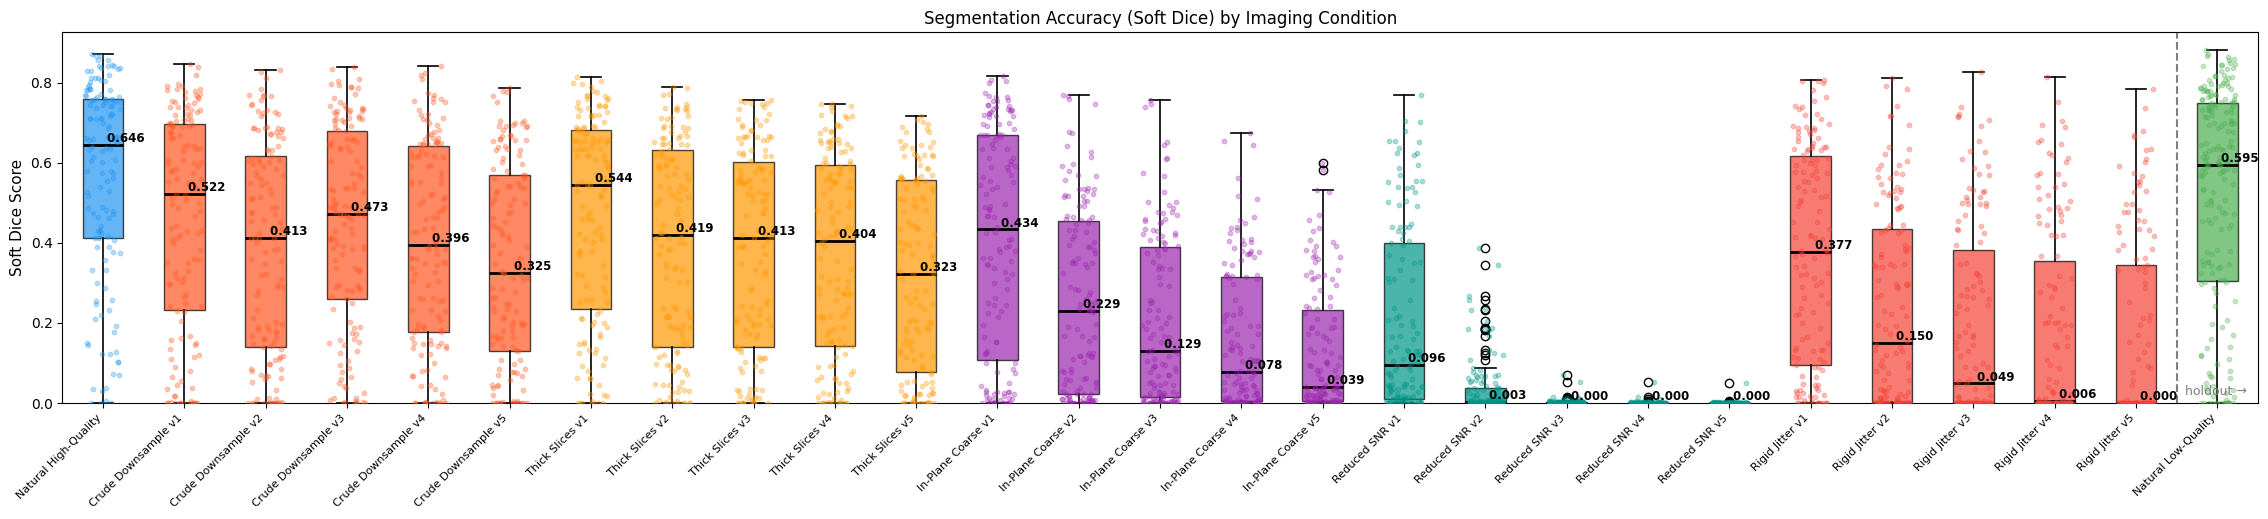


Figure 1 — Dice distribution summary by imaging condition:


,role,n,median_dice,mean_dice,std_dice,q25,q75,iqr,pct_zero
variant,,,,,,,,,
Natural High-Quality,Training,138,0.646,0.562,0.250,0.412,0.760,0.348,0.0
Crude Downsample v1,Training,138,0.522,0.456,0.270,0.233,0.698,0.465,0.7
Crude Downsample v2,Training,138,0.413,0.385,0.263,0.141,0.616,0.475,0.0
Crude Downsample v3,Training,138,0.473,0.448,0.251,0.260,0.681,0.421,0.0
Crude Downsample v4,Training,138,0.396,0.401,0.252,0.178,0.643,0.465,0.7
Crude Downsample v5,Training,138,0.325,0.348,0.248,0.129,0.569,0.440,0.7
Thick Slices v1,Training,138,0.544,0.466,0.253,0.236,0.681,0.446,0.0
Thick Slices v2,Training,138,0.419,0.395,0.257,0.140,0.633,0.493,0.0
Thick Slices v3,Training,138,0.413,0.380,0.250,0.140,0.601,0.461,0.0


In [10]:
FAMILY_LABELS = {
    "hires": "Natural High-Quality",
    "crude": "Crude Downsample",
    "thick_slice": "Thick Slices",
    "inplane_coarsening": "In-Plane Coarse",
    "reduced_snr": "Reduced SNR",
    "rigid_jitter": "Rigid Jitter",
    "lower_resolution": "Natural Low-Quality",
}
FAMILY_COLORS = {
    "hires": "#2196F3",
    "crude": "#FF5722",
    "thick_slice": "#FF9800",
    "inplane_coarsening": "#9C27B0",
    "reduced_snr": "#009688",
    "rigid_jitter": "#F44336",
    "lower_resolution": "#4CAF50",
}

def _variant_family(variant: str) -> str:
    text = str(variant)
    if text in {"hires", "lower_resolution"}:
        return text
    for prefix, family in [
        ("crude_v", "crude"),
        ("thick_slice_v", "thick_slice"),
        ("inplane_coarsening_v", "inplane_coarsening"),
        ("reduced_snr_v", "reduced_snr"),
        ("rigid_jitter_v", "rigid_jitter"),
    ]:
        if text.startswith(prefix):
            return family
    return text

def _variant_level(variant: str):
    text = str(variant)
    if "_v" not in text:
        return None
    try:
        return int(text.rsplit("_v", 1)[1])
    except ValueError:
        return None

def _variant_label(variant: str) -> str:
    family = _variant_family(variant)
    if family in {"hires", "lower_resolution"}:
        return FAMILY_LABELS.get(family, str(variant))
    level = _variant_level(variant)
    base = FAMILY_LABELS.get(family, str(variant))
    return f"{base} v{level}" if level is not None else base

available_variants = set(all_df["variant"].astype(str).unique())
VARIANT_LABELS = {v: _variant_label(v) for v in available_variants}
VARIANT_COLORS = {v: FAMILY_COLORS.get(_variant_family(v), "#9e9e9e") for v in available_variants}

SAVE_DIR = Path(RUN_DIR)
variant_order = [v for v in DEGRADED_VARIANTS + HOLDOUT_VARIANTS if v in available_variants]
fig, ax = plt.subplots(figsize=(max(18, 0.7 * len(variant_order) + 4), 6))
dice_arrays = []
for v in variant_order:
    source_df = holdout_df if v in HOLDOUT_VARIANTS else train_df
    dice_arrays.append(source_df[source_df["variant"] == v]["soft_dice"].dropna().values)

bp = ax.boxplot(dice_arrays, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
for patch, v in zip(bp["boxes"], variant_order):
    patch.set_facecolor(VARIANT_COLORS.get(v, "#aaa"))
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for j, (arr, v) in enumerate(zip(dice_arrays, variant_order)):
    jx = rng.uniform(j + 0.78, j + 1.22, size=len(arr))
    ax.scatter(jx, arr, alpha=0.3, s=10, color=VARIANT_COLORS.get(v, "#aaa"), zorder=3)

# Add median value labels on the black median bars
for j, arr in enumerate(dice_arrays):
    med = float(np.median(arr))
    ax.text(j + 1, med, f" {med:.3f}", va="bottom", ha="left",
            fontsize=8.5, color="black", fontweight="bold", zorder=5)

ax.set_xticks(range(1, len(variant_order) + 1))
ax.set_xticklabels([VARIANT_LABELS.get(v, v) for v in variant_order], fontsize=8, rotation=45, ha="right")
ax.set_ylabel("Soft Dice Score", fontsize=11)
ax.set_title("Segmentation Accuracy (Soft Dice) by Imaging Condition", fontsize=12)
ax.axvline(len(DEGRADED_VARIANTS) + 0.5, color="gray", linestyle="--", lw=1.5)
ax.text(len(DEGRADED_VARIANTS) + 0.6, 0.02, "holdout →", fontsize=9, color="gray")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.subplots_adjust(bottom=0.32)
plt.savefig(SAVE_DIR / "fig1_dice_by_variant.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-variant Dice summary table ────────────────────────────────────────────
_fig1_rows = []
for arr, v in zip(dice_arrays, variant_order):
    _fig1_rows.append({
        "variant":      VARIANT_LABELS.get(v, v),
        "role":         "Holdout" if v in HOLDOUT_VARIANTS else "Training",
        "n":            len(arr),
        "median_dice":  round(float(np.median(arr)), 3),
        "mean_dice":    round(float(np.mean(arr)),   3),
        "std_dice":     round(float(np.std(arr)),    3),
        "q25":          round(float(np.percentile(arr, 25)), 3),
        "q75":          round(float(np.percentile(arr, 75)), 3),
        "iqr":          round(float(np.percentile(arr, 75) - np.percentile(arr, 25)), 3),
        "pct_zero":     round(100.0 * float(np.mean(arr == 0)), 1),
    })

_fig1_df = pd.DataFrame(_fig1_rows).set_index("variant")
print("\nFigure 1 — Dice distribution summary by imaging condition:")
display(_fig1_df)


## Figure 1: Dice Score Distribution by Imaging Condition — Interpretation

**What the plot shows:** Box plots with jittered dots for each imaging condition (Natural High-Quality, multiple synthetic degradation-intensity variants, and the held-out Natural Low-Quality cohort). The box spans the IQR, the line is the median, and the whiskers extend to 1.5× IQR.

**Key findings and their meaning for stroke lesion segmentation:**

- **HiRes (Natural High-Quality) as ceiling:** The HiRes box represents the best achievable Dice for this model and patient population under ideal imaging conditions. Any reduction in median Dice for degraded variants directly quantifies the cost of image quality loss, giving a worst-case bound for clinical deployment on lower-quality scanners.
- **pct_zero (Dice = 0 cases):** Rows with high pct_zero indicate that the model completely misses the lesion for a non-trivial fraction of subjects under that imaging condition. A jump in pct_zero from HiRes to a degraded variant isolates detection failures from boundary-precision failures — they require different remediation (harder negative mining vs. resolution augmentation).
- **IQR and spread:** A large IQR in the degraded variants (compared to HiRes) signals that some patients are harmed much more than others by the degradation, likely those with small or low-contrast lesions. This heterogeneity motivates subject-level modelling (which the mixed-effects model addresses) rather than a single population-level metric.
- **Natural Low-Quality holdout (separated by dashed line):** The Natural Low-Res box uses a different patient cohort, so absolute Dice differences vs. degraded variants may reflect both population and image-quality effects. If the Natural Low-Res median is substantially lower than even the worst synthetic degradation, the synthetic augmentation strategy may be insufficient for the real clinical distribution.
- **Practical ordering:** If ThickSlices and InPlaneCoarse show the lowest medians among the synthetic variants, this is consistent with those methods producing the most FWHM increase and perilesional contrast attenuation (as quantified in the IQM notebook), providing cross-notebook validation of the imaging physics interpretation.


**§ 14 — Figure 2: Requested mixed-effects model suite diagnostics.** Each requested continuous mixed-effects specification is shown as a four-panel figure: fixed-effect coefficients, ICC variance decomposition, fixed-effect-only holdout calibration, and marginal/conditional R². This replaces the original notebook's single-model coefficient plot, lesion-volume plot, holdout calibration plot, ICC plot, and later categorical family-model comparison.


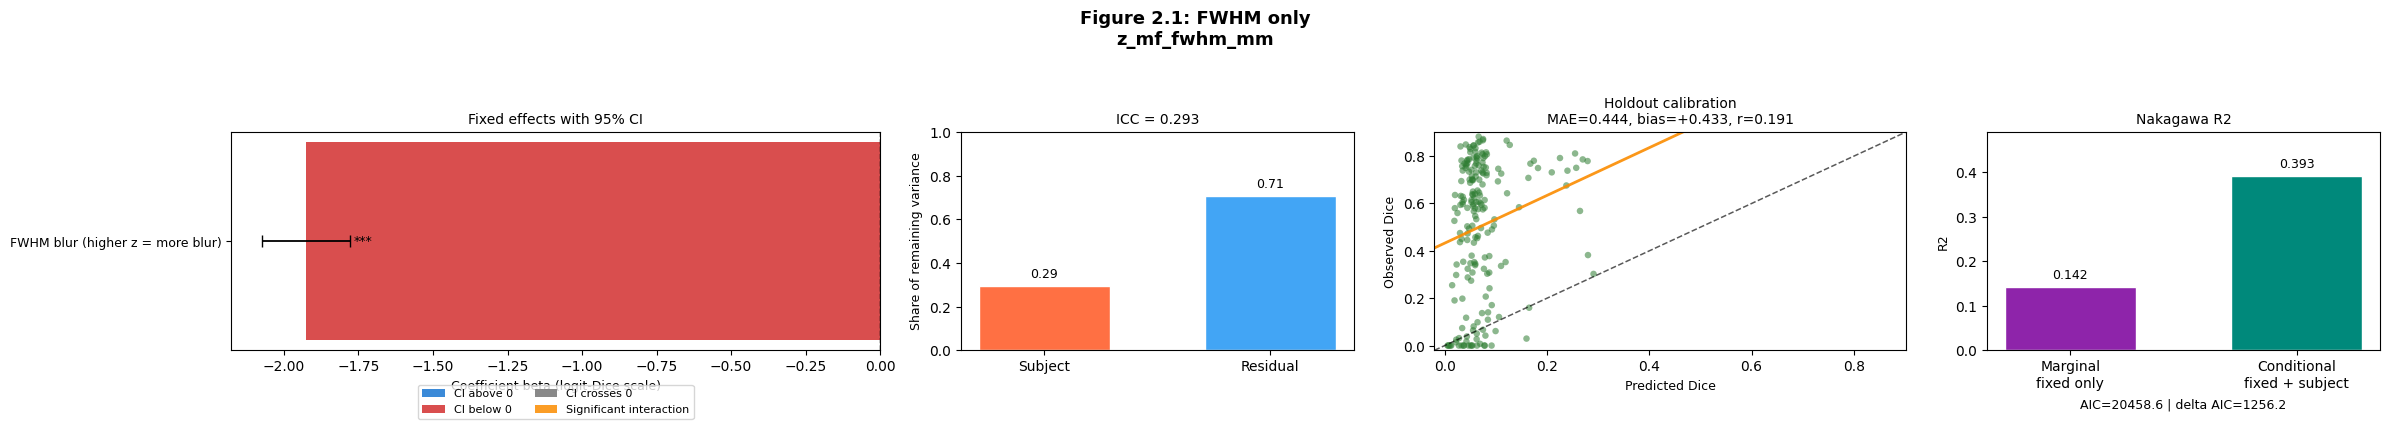


FWHM only: coefficient table (baseline Dice ~= 0.022)


,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,
FWHM blur (higher z = more blur),-1.9259,-2.0723,-1.7796,0.0,***,-0.019


  ICC=0.293 | marginal R2=0.142 | conditional R2=0.393 | holdout MAE=0.444


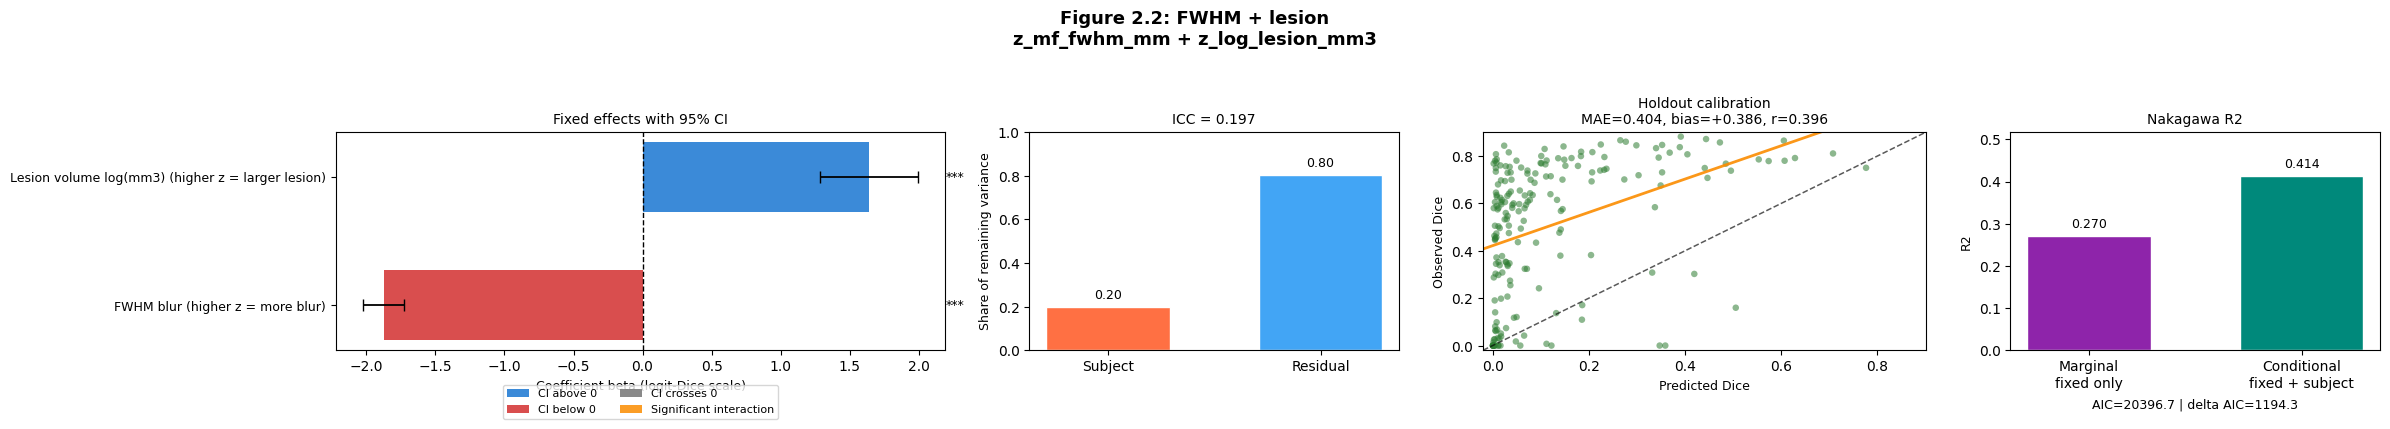


FWHM + lesion: coefficient table (baseline Dice ~= 0.022)


,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,
FWHM blur (higher z = more blur),-1.8755,-2.0217,-1.7293,0.0,***,-0.0188
Lesion volume log(mm3) (higher z = larger lesion),1.6376,1.2821,1.9931,0.0,***,0.0827


  ICC=0.197 | marginal R2=0.270 | conditional R2=0.414 | holdout MAE=0.404


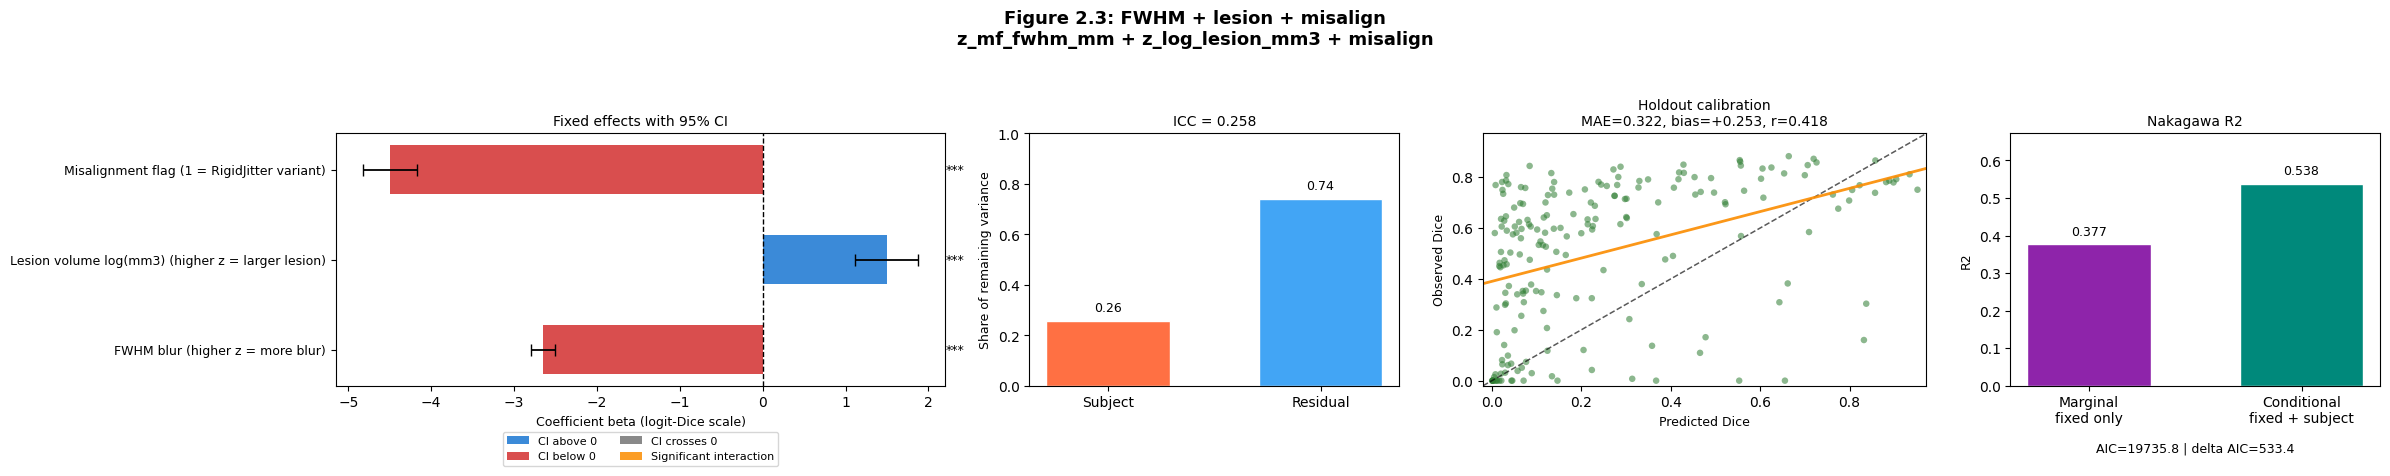


FWHM + lesion + misalign: coefficient table (baseline Dice ~= 0.051)


,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,
FWHM blur (higher z = more blur),-2.6461,-2.7904,-2.5018,0.0,***,-0.0475
Lesion volume log(mm3) (higher z = larger lesion),1.4939,1.1177,1.8701,0.0,***,0.1430
Misalignment flag (1 = RigidJitter variant),-4.4925,-4.8175,-4.1674,0.0,***,-0.0508


  ICC=0.258 | marginal R2=0.377 | conditional R2=0.538 | holdout MAE=0.322


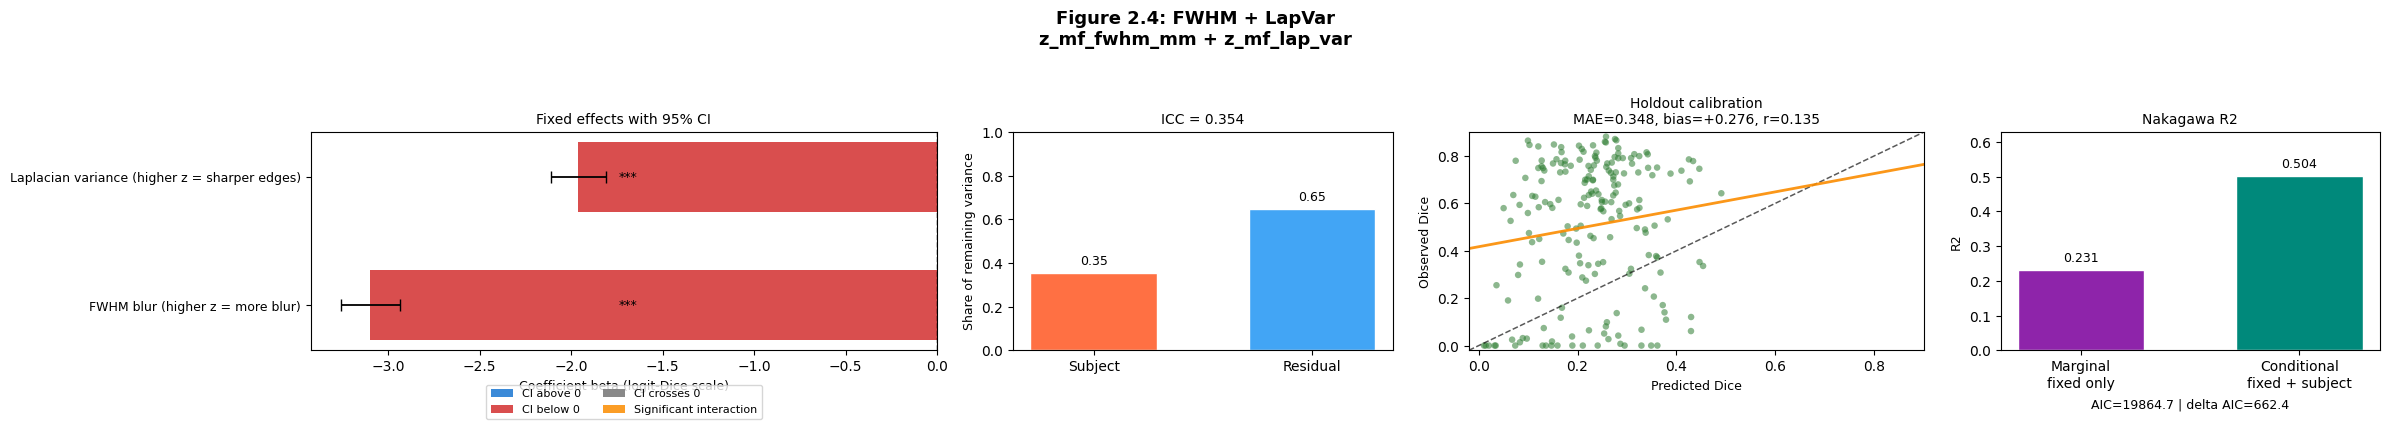


FWHM + LapVar: coefficient table (baseline Dice ~= 0.022)


,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,
FWHM blur (higher z = more blur),-3.0979,-3.2596,-2.9362,0.0,***,-0.0213
Laplacian variance (higher z = sharper edges),-1.9613,-2.1118,-1.8108,0.0,***,-0.0191


  ICC=0.354 | marginal R2=0.231 | conditional R2=0.504 | holdout MAE=0.348


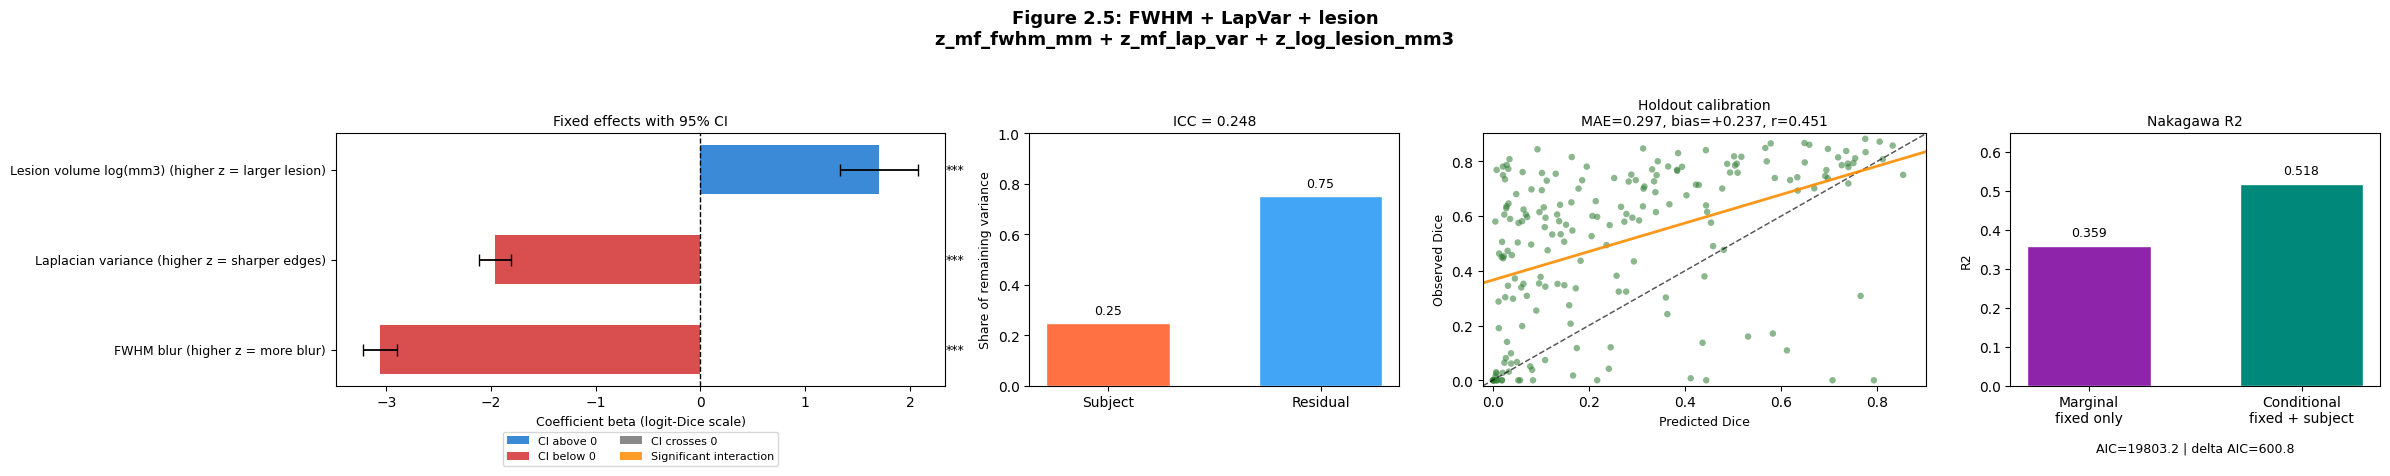


FWHM + LapVar + lesion: coefficient table (baseline Dice ~= 0.022)


,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,
FWHM blur (higher z = more blur),-3.0562,-3.2178,-2.8945,0.0,***,-0.0212
Laplacian variance (higher z = sharper edges),-1.9601,-2.1105,-1.8096,0.0,***,-0.0191
Lesion volume log(mm3) (higher z = larger lesion),1.7029,1.3318,2.0740,0.0,***,0.0890


  ICC=0.248 | marginal R2=0.359 | conditional R2=0.518 | holdout MAE=0.297


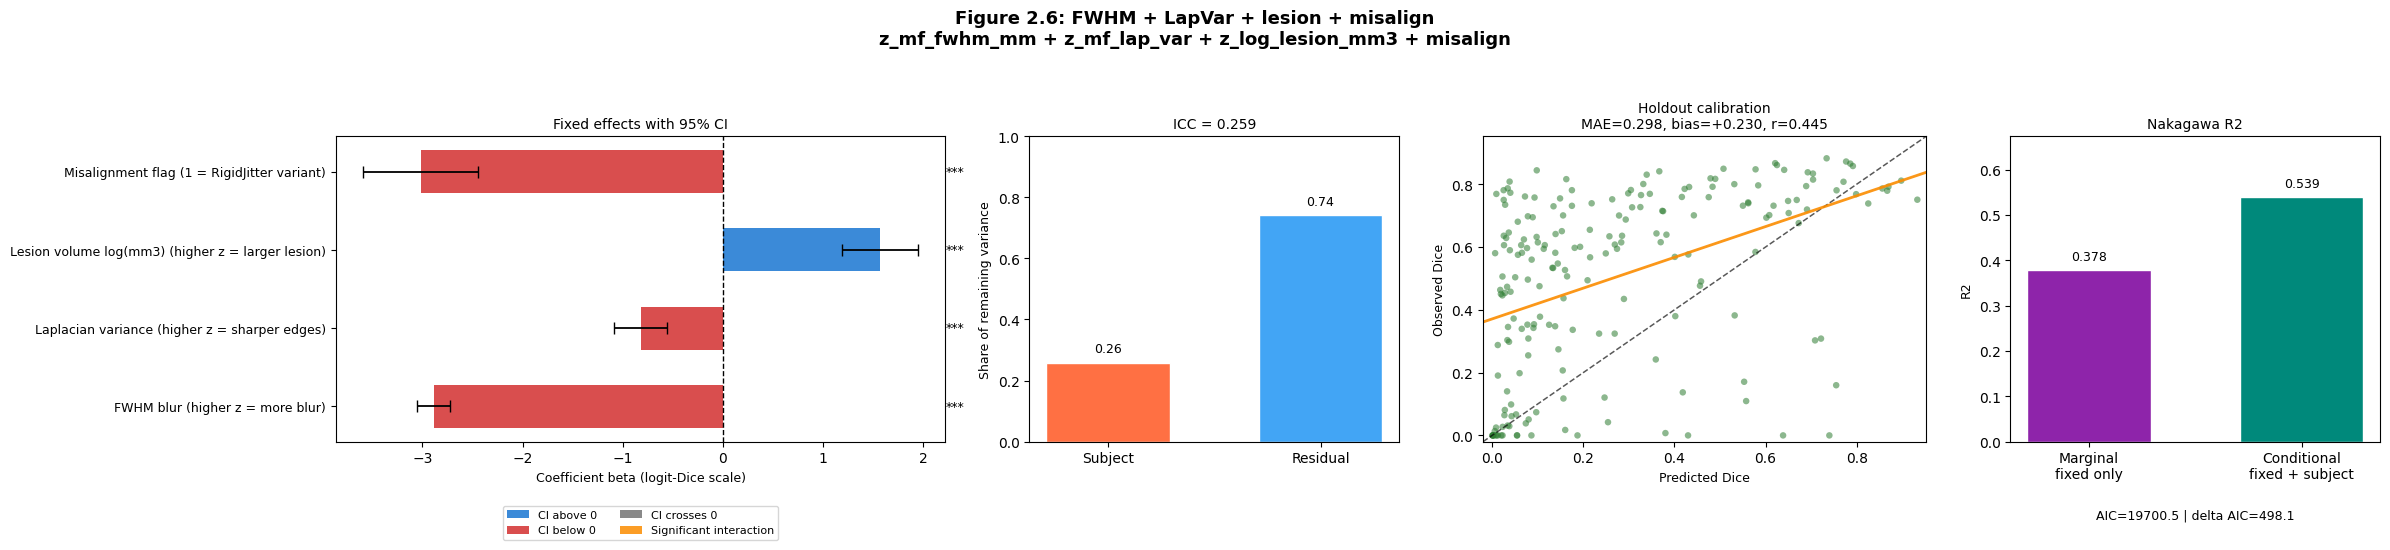


FWHM + LapVar + lesion + misalign: coefficient table (baseline Dice ~= 0.039)


,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,
FWHM blur (higher z = more blur),-2.8864,-3.0491,-2.7237,0.0,***,-0.0369
Laplacian variance (higher z = sharper edges),-0.8202,-1.0827,-0.5577,0.0,***,-0.0215
Lesion volume log(mm3) (higher z = larger lesion),1.5685,1.1930,1.9441,0.0,***,0.1244
Misalignment flag (1 = RigidJitter variant),-3.0146,-3.5877,-2.4416,0.0,***,-0.0372


  ICC=0.259 | marginal R2=0.378 | conditional R2=0.539 | holdout MAE=0.298


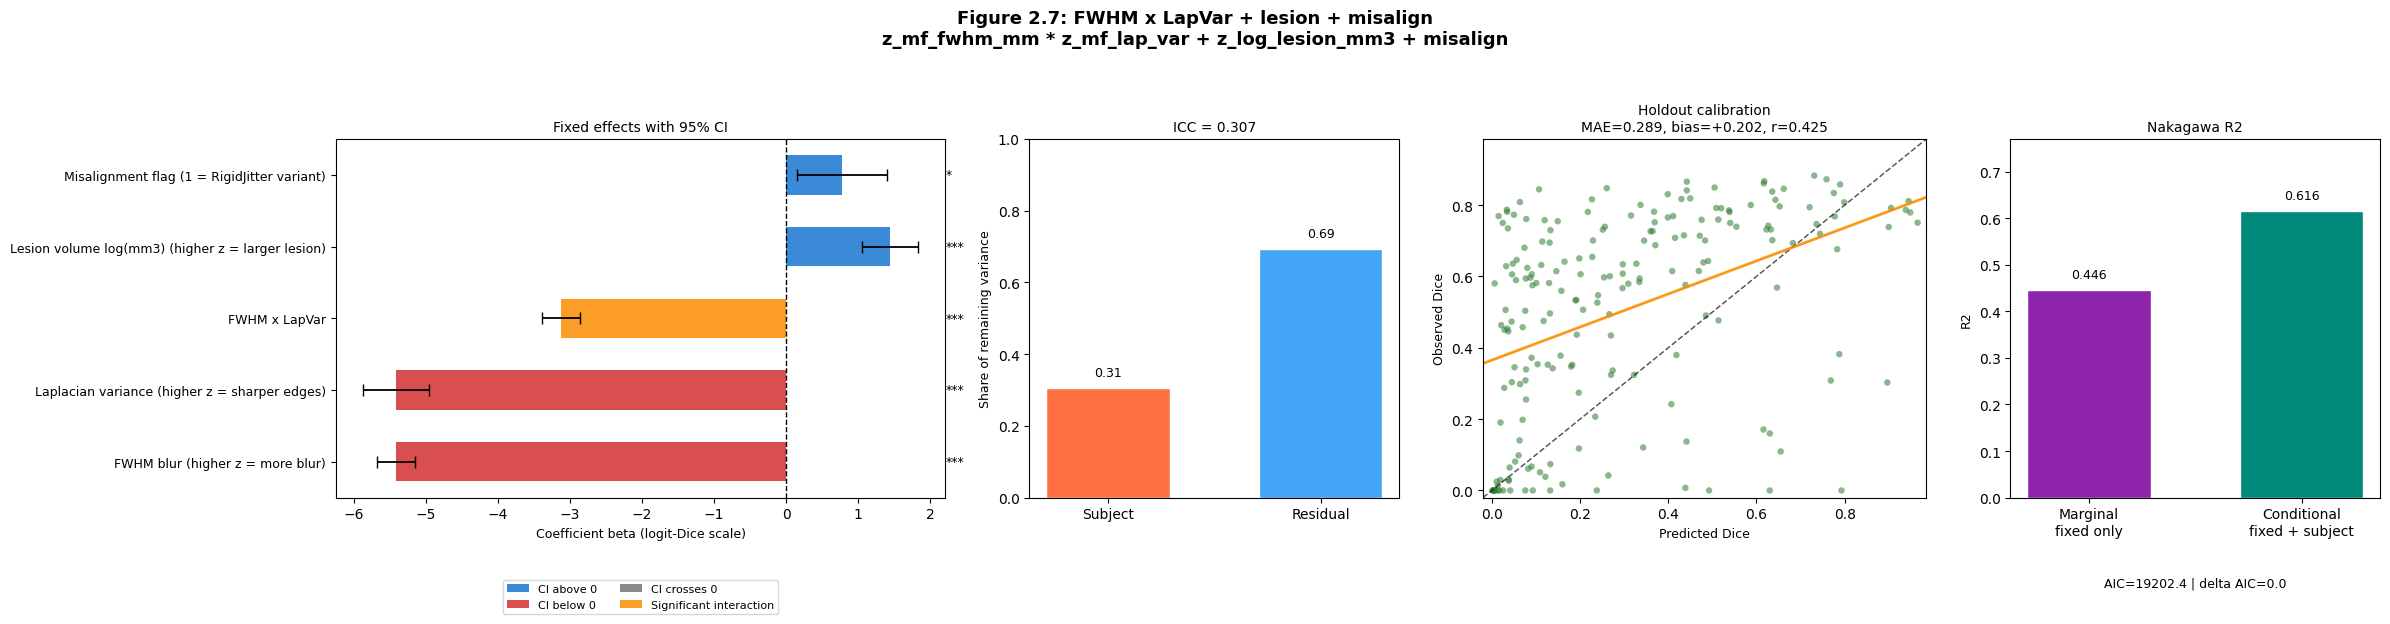


FWHM x LapVar + lesion + misalign: coefficient table (baseline Dice ~= 0.003)


,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,
FWHM blur (higher z = more blur),-5.4213,-5.6830,-5.1597,0.0000,***,-0.0030
Laplacian variance (higher z = sharper edges),-5.4116,-5.8696,-4.9536,0.0000,***,-0.0030
FWHM x LapVar,-3.1289,-3.3930,-2.8649,0.0000,***,-0.0029
Lesion volume log(mm3) (higher z = larger lesion),1.4410,1.0529,1.8290,0.0000,***,0.0097
Misalignment flag (1 = RigidJitter variant),0.7737,0.1517,1.3956,0.0148,*,0.0035


  ICC=0.307 | marginal R2=0.446 | conditional R2=0.616 | holdout MAE=0.289

Model-suite summary sorted by AIC:


,model,AIC,delta_AIC,ICC,r2_marginal,r2_conditional,holdout_mae,holdout_bias,holdout_r
6,FWHM x LapVar + lesion + misalign,19202.3830,0.0000,0.3067,0.4461,0.6160,0.2893,0.2024,0.4248
5,FWHM + LapVar + lesion + misalign,19700.5271,498.1441,0.2591,0.3782,0.5393,0.2979,0.2303,0.4448
2,FWHM + lesion + misalign,19735.8290,533.4460,0.2584,0.3767,0.5377,0.3222,0.2530,0.4181
4,FWHM + LapVar + lesion,19803.1955,600.8125,0.2484,0.3587,0.5180,0.2969,0.2374,0.4510
3,FWHM + LapVar,19864.7432,662.3602,0.3540,0.2315,0.5035,0.3482,0.2762,0.1352
1,FWHM + lesion,20396.6839,1194.3010,0.1969,0.2704,0.4141,0.4036,0.3863,0.3958
0,FWHM only,20458.5800,1256.1970,0.2926,0.1416,0.3927,0.4439,0.4332,0.1912


In [11]:
from matplotlib.patches import Patch


def _term_label(term):
    return TERM_LABELS.get(term, term).replace("\n", " ")


def _safe_filename(name):
    return (
        name.lower()
        .replace(" + ", "_")
        .replace(" ", "_")
        .replace("x", "x")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )


def _coef_color(ci_low, ci_high, term):
    if ":" in term:
        return "#fb8c00" if (ci_low > 0 or ci_high < 0) else "#9e9e9e"
    if ci_high < 0:
        return "#d32f2f"
    if ci_low > 0:
        return "#1976d2"
    return "#757575"


model_diagnostic_tables = {}
for model_idx, model_name in enumerate(MODEL_ORDER, start=1):
    if model_name not in compare_results:
        print(f"Figure 2.{model_idx}: {model_name} was not fitted; skipping plot.")
        continue

    result = compare_results[model_name]
    spec = _MODEL_SPEC_BY_NAME[model_name]
    comp_row = comparison_df.loc[comparison_df["model"] == model_name].iloc[0]
    pred_df = holdout_predictions.get(model_name)

    fe = result.fe_params
    ci = result.conf_int().rename(columns={0: "lo", 1: "hi"})
    pvals = result.pvalues
    terms = [term for term in fe.index if term != "Intercept"]

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(24, max(4.5, 0.72 * max(len(terms), 1) + 2.8)),
        gridspec_kw={"width_ratios": [1.65, 1.0, 1.2, 1.0]},
    )
    fig.suptitle(
        f"Figure 2.{model_idx}: {model_name}\n{spec['formula'].replace('logit_dice ~ ', '')}",
        fontsize=13,
        fontweight="bold",
        y=1.04,
    )

    # Panel 1: coefficient forest plot.
    ax = axes[0]
    if terms:
        coefs = fe.loc[terms].to_numpy(dtype=float)
        lo = ci.loc[terms, "lo"].to_numpy(dtype=float)
        hi = ci.loc[terms, "hi"].to_numpy(dtype=float)
        y_pos = np.arange(len(terms))
        labels = [_term_label(term) for term in terms]
        colors = [_coef_color(l_val, h_val, term) for l_val, h_val, term in zip(lo, hi, terms)]
        ax.barh(
            y_pos,
            coefs,
            xerr=[coefs - lo, hi - coefs],
            color=colors,
            alpha=0.85,
            error_kw=dict(ecolor="black", lw=1.3, capsize=4),
            height=0.55,
        )
        ax.axvline(0, color="black", linewidth=1.0, linestyle="--")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=9)
        ax.set_xlabel("Coefficient beta (logit-Dice scale)", fontsize=9)
        ax.set_title("Fixed effects with 95% CI", fontsize=10)
        span = max(float(np.nanmax(hi) - np.nanmin(lo)), 1e-6)
        x_star = float(np.nanmax(hi)) + span * 0.05
        for i, term in enumerate(terms):
            p_val = float(pvals.get(term, np.nan))
            star = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            ax.text(x_star, i, star, va="center", fontsize=9,
                    color="black" if star != "ns" else "gray")
    else:
        ax.text(0.5, 0.5, "Intercept-only model", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()

    # Panel 2: ICC variance decomposition.
    ax = axes[1]
    icc_val = float(comp_row["ICC"])
    resid_share = 1.0 - icc_val if np.isfinite(icc_val) else np.nan
    bars = ax.bar(
        ["Subject", "Residual"],
        [icc_val, resid_share],
        color=["#ff7043", "#42a5f5"],
        edgecolor="white",
        width=0.58,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of remaining variance", fontsize=9)
    ax.set_title(f"ICC = {icc_val:.3f}", fontsize=10)
    for bar in bars:
        h = float(bar.get_height())
        ax.text(bar.get_x() + bar.get_width() / 2, min(h + 0.025, 0.96), f"{h:.2f}",
                ha="center", va="bottom", fontsize=9)

    # Panel 3: holdout calibration.
    ax = axes[2]
    if pred_df is not None and len(pred_df):
        obs = pred_df[OUTCOME].to_numpy(dtype=float)
        pred = pred_df["pred_dice"].to_numpy(dtype=float)
        ax.scatter(pred, obs, alpha=0.55, s=22, color="#2e7d32", edgecolor="none")
        lo_line = float(np.nanmin([pred.min(), obs.min()])) - 0.02
        hi_line = float(np.nanmax([pred.max(), obs.max()])) + 0.02
        ax.plot([lo_line, hi_line], [lo_line, hi_line], "k--", lw=1.1, alpha=0.65)
        if np.isfinite(comp_row["holdout_r"]):
            fit = np.polyfit(pred, obs, 1)
            line = np.linspace(lo_line, hi_line, 100)
            ax.plot(line, np.polyval(fit, line), color="#fb8c00", lw=2.0, alpha=0.9)
        ax.set_xlim(lo_line, hi_line)
        ax.set_ylim(lo_line, hi_line)
        ax.set_xlabel("Predicted Dice", fontsize=9)
        ax.set_ylabel("Observed Dice", fontsize=9)
        ax.set_title(
            f"Holdout calibration\nMAE={comp_row['holdout_mae']:.3f}, bias={comp_row['holdout_bias']:+.3f}, r={comp_row['holdout_r']:.3f}",
            fontsize=10,
        )
    else:
        err = comp_row.get("error", None)
        ax.text(0.5, 0.5, f"Holdout prediction unavailable\n{err or ''}",
                ha="center", va="center", transform=ax.transAxes, fontsize=9)
        ax.set_axis_off()

    # Panel 4: marginal and conditional R2.
    ax = axes[3]
    r2_vals = [float(comp_row["r2_marginal"]), float(comp_row["r2_conditional"])]
    r2_labels = ["Marginal\nfixed only", "Conditional\nfixed + subject"]
    bars = ax.bar(r2_labels, r2_vals, color=["#8e24aa", "#00897b"], edgecolor="white", width=0.58)
    ymax = min(1.0, max(0.1, np.nanmax(r2_vals) * 1.25))
    ax.set_ylim(0, ymax)
    ax.set_ylabel("R2", fontsize=9)
    ax.set_title("Nakagawa R2", fontsize=10)
    for bar in bars:
        h = float(bar.get_height())
        ax.text(bar.get_x() + bar.get_width() / 2, h + ymax * 0.025, f"{h:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.text(
        0.5,
        -0.22,
        f"AIC={comp_row['AIC']:.1f} | delta AIC={comp_row['delta_AIC']:.1f}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

    legend_handles = [
        Patch(facecolor="#1976d2", alpha=0.85, label="CI above 0"),
        Patch(facecolor="#d32f2f", alpha=0.85, label="CI below 0"),
        Patch(facecolor="#757575", alpha=0.85, label="CI crosses 0"),
        Patch(facecolor="#fb8c00", alpha=0.85, label="Significant interaction"),
    ]
    axes[0].legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.34),
                   ncol=2, fontsize=8, frameon=True)

    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"fig2_{model_idx:02d}_{_safe_filename(model_name)}_four_panel_diagnostics.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    _intercept = float(fe.get("Intercept", 0.0))
    _baseline_dice = float(_expit(_intercept))
    rows = []
    for term in terms:
        beta = float(fe[term])
        p_val = float(pvals.get(term, np.nan))
        rows.append({
            "term": _term_label(term),
            "beta_logit": beta,
            "ci95_low": float(ci.loc[term, "lo"]),
            "ci95_high": float(ci.loc[term, "hi"]),
            "p_value": p_val,
            "sig": "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns",
            "approx_delta_dice": float(_expit(_intercept + beta) - _baseline_dice),
        })
    coef_table = pd.DataFrame(rows).set_index("term") if rows else pd.DataFrame()
    model_diagnostic_tables[model_name] = coef_table
    print(f"\n{model_name}: coefficient table (baseline Dice ~= {_baseline_dice:.3f})")
    if len(coef_table):
        display(coef_table.round(4))
    print(
        f"  ICC={comp_row['ICC']:.3f} | marginal R2={comp_row['r2_marginal']:.3f} | "
        f"conditional R2={comp_row['r2_conditional']:.3f} | holdout MAE={comp_row['holdout_mae']:.3f}"
    )

print("\nModel-suite summary sorted by AIC:")
display(comparison_df.sort_values("AIC")[[
    "model", "AIC", "delta_AIC", "ICC", "r2_marginal", "r2_conditional", "holdout_mae", "holdout_bias", "holdout_r"
]].round(4))


## Figure 2: Mixed-Effects Model Suite — Interpretation

Each requested model now gets the same four-panel diagnostic view: coefficient forest plot, ICC, holdout calibration, and marginal/conditional R². The direct misalignment comparison is the pairwise contrast between `FWHM + lesion` and `FWHM + lesion + misalign`, then between `FWHM + LapVar + lesion` and `FWHM + LapVar + lesion + misalign`. Negative `delta_AIC_with_minus_without` or negative `delta_holdout_MAE_with_minus_without` means the misalignment flag improved that comparison.

Read the FWHM-only model as the unadjusted blur effect; the lesion-volume models show how much of that blur penalty is explained by lesion size; the misalignment models quantify whether the RigidJitter flag adds information beyond continuous FWHM/LapVar. The interaction model tests whether LapVar changes the FWHM penalty rather than acting as a simple additive predictor.


**§ 19 — Figure 7: Per-variant Summary Statistics Table.**
A concise table of the key numbers a reviewer will look for: how many subjects, mean and standard deviation of hard Dice, detection rate (fraction of subjects where the model found *any* lesion, i.e. Dice > 0), and mean lesion volume. This is the standard results table format for lesion segmentation papers.


In [12]:
VARIANT_ORDER = [v for v in DEGRADED_VARIANTS + HOLDOUT_VARIANTS if v in set(all_df["variant"].astype(str).unique())]
VARIANT_LABEL_MAP = {
    v: (VARIANT_LABELS.get(v, v) + " (holdout)" if v in HOLDOUT_VARIANTS else VARIANT_LABELS.get(v, v))
    for v in VARIANT_ORDER
}

rows = []
for v in VARIANT_ORDER:
    sub = all_df[all_df["variant"] == v]
    n   = len(sub)
    if n == 0:
        continue

    dice_col = "hard_dice_at_0.50" if "hard_dice_at_0.50" in sub.columns else "soft_dice"
    dice     = sub[dice_col].dropna()
    detected = (dice > 0).sum()

    les_col  = "lesion_mm3" if "lesion_mm3" in sub.columns else None

    rows.append({
        "Variant":              VARIANT_LABEL_MAP.get(v, v),
        "Role":                 "Holdout" if v in HOLDOUT_VARIANTS else "Training",
        "N subjects":           n,
        "Mean Dice ± SD":       f"{dice.mean():.3f} ± {dice.std():.3f}",
        "Median Dice":          f"{dice.median():.3f}",
        "Detection rate":       f"{detected}/{n} ({100*detected/n:.0f}%)",
        "Mean lesion (mm³)":    f"{sub[les_col].mean():.0f}" if les_col else "—",
    })

summary_table = pd.DataFrame(rows).set_index("Variant")
print("Per-variant segmentation performance summary\n")
summary_table


Per-variant segmentation performance summary



,Role,N subjects,Mean Dice ± SD,Median Dice,Detection rate,Mean lesion (mm³)
Variant,,,,,,
Natural High-Quality,Training,138,0.562 ± 0.250,0.646,135/138 (98%),33696
Crude Downsample v1,Training,138,0.456 ± 0.271,0.522,127/138 (92%),33696
Crude Downsample v2,Training,138,0.385 ± 0.264,0.412,125/138 (91%),33696
Crude Downsample v3,Training,138,0.448 ± 0.251,0.473,134/138 (97%),33696
Crude Downsample v4,Training,138,0.401 ± 0.253,0.395,129/138 (93%),33696
Crude Downsample v5,Training,138,0.348 ± 0.249,0.325,125/138 (91%),33696
Thick Slices v1,Training,138,0.466 ± 0.253,0.544,133/138 (96%),33696
Thick Slices v2,Training,138,0.395 ± 0.258,0.419,131/138 (95%),33696
Thick Slices v3,Training,138,0.380 ± 0.251,0.413,131/138 (95%),33696


**§ 20 — Figure 8: Detection Rate and Dice-Among-Detected.**
Reporting overall mean Dice conflates two different failure modes: (1) the model completely misses a lesion (Dice = 0, a *detection* failure) and (2) the model finds something but the overlap is imperfect (a *segmentation quality* failure). Separating these gives a clearer picture. The left panel shows what fraction of subjects had any lesion detected (Dice > 0) per variant. The right panel shows mean Dice restricted to detected subjects only, removing the floor effect from missed lesions.


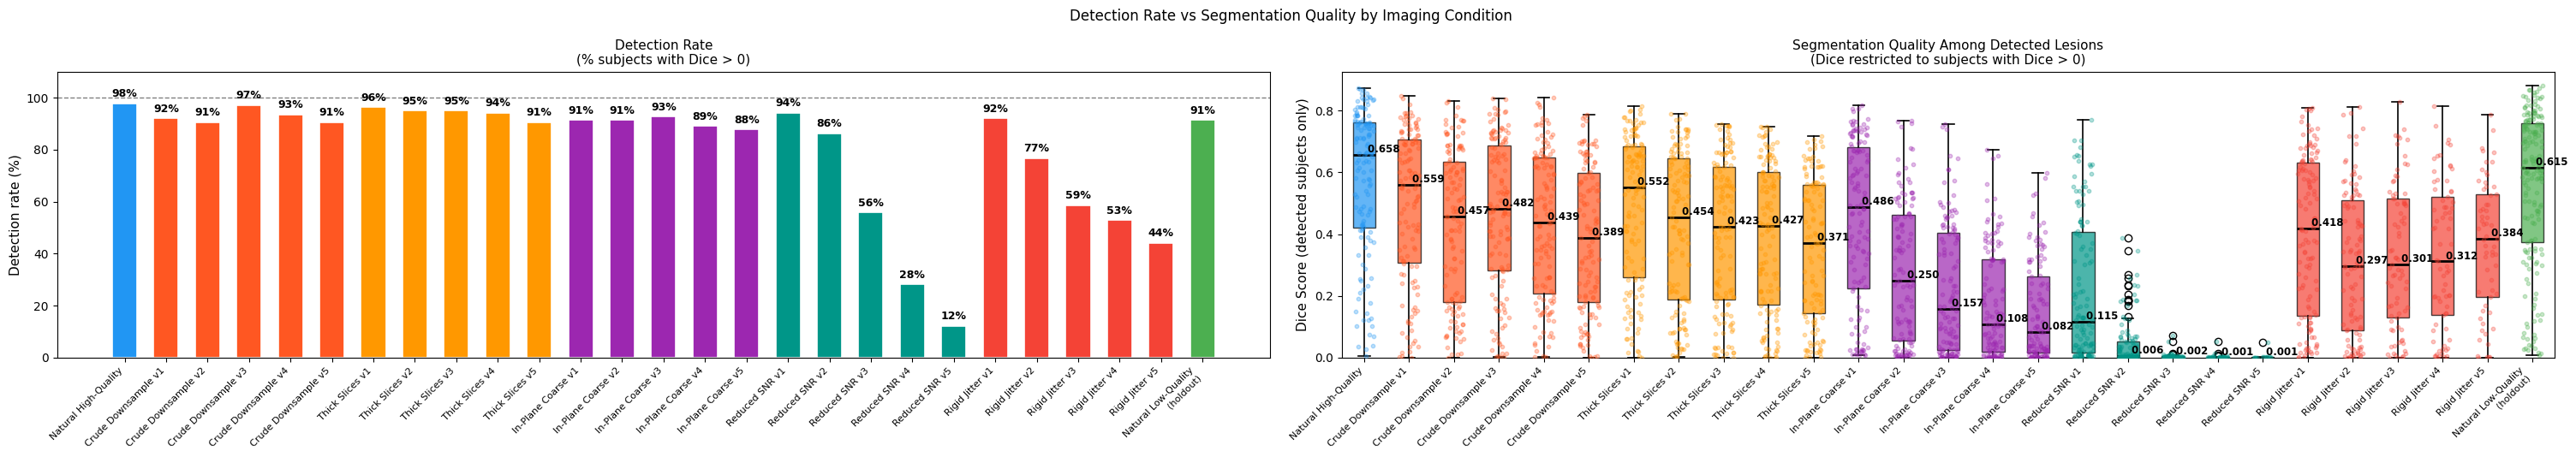


Figure 8 — Detection rate and Dice-among-detected summary:
  delta_det_vs_all: how much detection failures drag down overall mean Dice


,role,n_total,n_detected,det_rate_pct,median_dice_detected,mean_dice_detected,mean_dice_all,delta_det_vs_all
variant,,,,,,,,
Natural High-Quality,Training,138,135,97.8,0.658,0.575,0.562,0.012
Crude Downsample v1,Training,138,127,92.0,0.559,0.495,0.456,0.039
Crude Downsample v2,Training,138,125,90.6,0.457,0.426,0.385,0.040
Crude Downsample v3,Training,138,134,97.1,0.482,0.461,0.448,0.013
Crude Downsample v4,Training,138,129,93.5,0.439,0.429,0.401,0.028
Crude Downsample v5,Training,138,125,90.6,0.389,0.384,0.348,0.036
Thick Slices v1,Training,138,133,96.4,0.552,0.484,0.466,0.018
Thick Slices v2,Training,138,131,94.9,0.454,0.416,0.395,0.021
Thick Slices v3,Training,138,131,94.9,0.423,0.400,0.380,0.020


In [13]:
dice_col = "hard_dice_at_0.50" if "hard_dice_at_0.50" in all_df.columns else "soft_dice"

# Build per-variant arrays of detected-only Dice
det_rates, dice_detected_arrays, labels_plot, colors_plot = [], [], [], []
for v in VARIANT_ORDER:
    sub  = all_df[all_df["variant"] == v]
    dice = sub[dice_col].dropna()
    if len(dice) == 0:
        continue
    det_rates.append(100 * (dice > 0).mean())
    dice_detected_arrays.append(dice[dice > 0].values)
    labels_plot.append(VARIANT_LABEL_MAP.get(v, v).replace(" (holdout)", "\n(holdout)"))
    colors_plot.append(VARIANT_COLORS.get(v, "#aaa"))

x = np.arange(len(labels_plot))

fig, axes = plt.subplots(1, 2, figsize=(max(20, 0.75 * len(labels_plot) + 10), 6))
fig.suptitle("Detection Rate vs Segmentation Quality by Imaging Condition", fontsize=12)

# ── Left panel: Detection rate bar chart ──────────────────────────────────────
ax = axes[0]
bar_kw = dict(edgecolor="white", linewidth=1.2, width=0.6)
bars = ax.bar(x, det_rates, color=colors_plot, **bar_kw)
ax.set_xticks(x); ax.set_xticklabels(labels_plot, fontsize=8, rotation=45, ha="right")
ax.set_ylabel("Detection rate (%)", fontsize=11)
ax.set_ylim(0, 110)
ax.set_title("Detection Rate\n(% subjects with Dice > 0)", fontsize=11)
ax.axhline(100, color="gray", linestyle="--", lw=1)
for bar, val in zip(bars, det_rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── Right panel: Dice-among-detected — box-whisker matching Fig 1 style ───────
ax = axes[1]
bp = ax.boxplot(dice_detected_arrays, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
for patch, col in zip(bp["boxes"], colors_plot):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for j, (arr, col) in enumerate(zip(dice_detected_arrays, colors_plot)):
    jx = rng.uniform(j + 0.78, j + 1.22, size=len(arr))
    ax.scatter(jx, arr, alpha=0.3, s=10, color=col, zorder=3)

# Median value labels on the black median bars
for j, arr in enumerate(dice_detected_arrays):
    med = float(np.median(arr))
    ax.text(j + 1, med, f" {med:.3f}", va="bottom", ha="left",
            fontsize=8.5, color="black", fontweight="bold", zorder=5)

ax.set_xticks(range(1, len(labels_plot) + 1))
ax.set_xticklabels(labels_plot, fontsize=8, rotation=45, ha="right")
ax.set_ylabel("Dice Score (detected subjects only)", fontsize=11)
ax.set_ylim(bottom=0)
ax.set_title("Segmentation Quality Among Detected Lesions\n(Dice restricted to subjects with Dice > 0)", fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.30)
plt.savefig(SAVE_DIR / "fig8_detection_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Detection vs quality summary table ────────────────────────────────────────
_det_rows = []
for v, det_r, det_arr, lbl in zip(VARIANT_ORDER[:len(det_rates)], det_rates, dice_detected_arrays, labels_plot):
    sub   = all_df[all_df["variant"] == v]
    dice  = sub[dice_col].dropna()
    n_tot = len(dice)
    n_det = int((dice > 0).sum())
    _det_rows.append({
        "variant":              lbl.replace("\n", " "),
        "role":                 "Holdout" if v in HOLDOUT_VARIANTS else "Training",
        "n_total":              n_tot,
        "n_detected":           n_det,
        "det_rate_pct":         round(float(det_r), 1),
        "median_dice_detected": round(float(np.median(det_arr)), 3) if len(det_arr) else float("nan"),
        "mean_dice_detected":   round(float(np.mean(det_arr)),   3) if len(det_arr) else float("nan"),
        "mean_dice_all":        round(float(dice.mean()), 3),
        "delta_det_vs_all":     round(float(np.mean(det_arr) - dice.mean()), 3) if len(det_arr) else float("nan"),
    })

_det_df = pd.DataFrame(_det_rows).set_index("variant")
print("\nFigure 8 — Detection rate and Dice-among-detected summary:")
print("  delta_det_vs_all: how much detection failures drag down overall mean Dice")
display(_det_df)


## Figure 8: Detection Rate vs Segmentation Quality — Interpretation

**What the plot shows:** Two bar charts: left shows the detection rate (% subjects where the model produces any non-zero Dice) per imaging condition; right shows the mean Dice *only among subjects where the lesion was detected*. This decomposition separates the two failure modes.

**Key findings and their meaning for stroke lesion segmentation:**

- **Two orthogonal failure modes:** Overall mean Dice conflates (a) the model completely missing a lesion (detection failure, Dice = 0) and (b) the model finding the lesion but with imprecise boundaries (quality failure, Dice > 0 but low). These require different fixes: detection failures call for recall-boosting training strategies (focal loss, harder negatives, lower detection threshold); quality failures call for boundary refinement and better resolution.
- **delta_det_vs_all:** This column quantifies how much detection failures drag down the reported mean Dice. A large delta (e.g. 0.10) means that if the model just detected all lesions, mean Dice would rise by 10 points — detection is the dominant bottleneck. A small delta means the model reliably finds lesions but struggles with boundary precision.
- **Detection rate under degradation:** If detection rate drops substantially (e.g. from 95% on HiRes to 78% on ThickSlices), it means degradation causes complete lesion misses, not just boundary errors. This is the most clinically severe failure — a completely missed lesion = no treatment planning guidance at all.
- **Quality (Dice-among-detected) under degradation:** If Dice-among-detected stays stable across variants while overall mean Dice drops, the degradation is causing more misses but not affecting the boundary quality of lesions the model does find. The model architecture may be robust to image quality in its boundary-drawing but fragile at the detection stage.
- **Natural Low-Res holdout comparison:** If the Natural Low-Res holdout shows a different detection/quality trade-off pattern from the synthetic variants (e.g., lower detection rate but higher Dice-among-detected), this reveals that the synthetic augmentation teaches the model to try harder on blurry images (reducing missed detections) but real low-res images have quality characteristics that don't match the synthetic distribution.
- **Actionable threshold:** Variants with det_rate < 90% should be flagged as needing targeted training intervention. Variants with high det_rate but mean_dice_detected < 0.50 are candidates for boundary-sharpening post-processing or test-time augmentation.


**§ 14 — Non-linear sensitivity analysis (cubic B-spline OLS).** Fits an ordinary-least-squares model with four-degree-of-freedom natural cubic B-spline basis expansions for each quality metric, with cluster-robust standard errors grouped by subject. This non-parametric alternative relaxes the linearity assumption of the primary LME and serves as a sensitivity check: close agreement between the spline and linear holdout metrics supports the adequacy of the linear specification; substantial divergence suggests non-linear quality–accuracy relationships that may warrant further investigation.

In [14]:
# Optional non-linear sensitivity model (GAM-like with cubic B-splines + clustered SEs)
if not active_predictors:
    print("No varying quality predictors available; skipping spline model.")
else:
    spline_terms = [f"bs({col}, df=4, degree=3, include_intercept=False)" for col in active_predictors]
    spline_formula = "1 + " + " + ".join(spline_terms)

    X_train = dmatrix(spline_formula, train_df, return_type="dataframe")
    if train_df["misalign"].nunique() > 1:
        X_train["misalign"] = train_df["misalign"].values

    spline_result = sm.OLS(train_df["logit_dice"], X_train).fit(
        cov_type="cluster",
        cov_kwds={"groups": train_df[GROUP_COL]},
    )

    print(spline_result.summary().tables[0])

    # Holdout prediction for comparison.
    # Clip to training bounds to avoid spline basis extrapolation errors.
    holdout_for_spline = holdout_df.copy()
    for col in active_predictors:
        lo = float(train_df[col].min())
        hi = float(train_df[col].max())
        holdout_for_spline[col] = holdout_for_spline[col].clip(lo, hi)

    X_holdout = dmatrix(X_train.design_info, holdout_for_spline, return_type="dataframe")
    for col in X_train.columns:
        if col not in X_holdout.columns:
            X_holdout[col] = 0.0
    X_holdout = X_holdout[X_train.columns]

    holdout_df["pred_logit_spline"] = spline_result.predict(X_holdout)
    holdout_df["pred_soft_dice_spline"] = expit(holdout_df["pred_logit_spline"])

    obs = holdout_df[OUTCOME].to_numpy(dtype=float)
    pred_spline = holdout_df["pred_soft_dice_spline"].to_numpy(dtype=float)
    res_spline = obs - pred_spline

    spline_metrics = pd.Series(
        {
            "mae_spline": float(np.mean(np.abs(res_spline))),
            "rmse_spline": float(np.sqrt(np.mean(res_spline ** 2))),
            "bias_spline": float(np.mean(res_spline)),
            "pearson_r_spline": float(np.corrcoef(obs, pred_spline)[0, 1]),
        }
    )
    print(spline_metrics.to_string())


                            OLS Regression Results                            
Dep. Variable:             logit_dice   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     129.8
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.54e-62
Time:                        12:28:13   Log-Likelihood:                -10222.
No. Observations:                3588   AIC:                         2.046e+04
Df Residuals:                    3578   BIC:                         2.053e+04
Df Model:                           9                                         
Covariance Type:              cluster                                         
mae_spline          0.295127
rmse_spline         0.358383
bias_spline         0.086369
pearson_r_spline    0.064202


## Interpretation Checklist

- Check whether quality predictors actually vary by degradation (see the within-key spread table).
- If predictors do not vary across cohorts, the model can only learn subject-level associations, not degradation penalties.
- Use the holdout calibration bias (`observed - predicted`) to quantify any additional natural low-res penalty.
- If needed, recompute quality metrics directly on degraded images before final manuscript-level inference.


**§ 21 — Fixed-effect collinearity diagnosis (Variance Inflation Factor).** Uses the exact fixed-effect design matrix from the fitted mixed-effects model (`mixed_result.model.exog`) to quantify how much collinearity is inflating the uncertainty of each remaining coefficient in the reduced v2 model. For predictor *j*, VIF\(_j\) = 1 / (1 − R²\(_j\)), where R²\(_j\) is obtained by regressing that predictor on all of the other fixed effects. A VIF near 1 indicates negligible collinearity; values above ~5 suggest meaningful inflation, and values above ~10 suggest severe instability. The square-root of VIF is especially useful here because it directly reports the multiplicative inflation in the coefficient standard error.

Variance Inflation Factor (VIF) diagnostics from the fitted mixed-model fixed-effect matrix:
  VIF quantifies how much predictor collinearity inflates coefficient variance.
  sqrt(VIF) is the corresponding standard-error inflation factor.


,label,vif,sqrt_vif,tolerance
term,,,,
z_mf_lap_var,Laplacian variance (higher z = sharper edges),4.49,2.12,0.223
misalign,Misalignment flag (1 = RigidJitter variant),3.29,1.81,0.304
z_mf_fwhm_mm,FWHM blur (higher z = more blur),1.71,1.31,0.586
z_log_lesion_mm3,Lesion volume log(mm3) (higher z = larger lesion),1.07,1.03,0.934


Top pairwise correlations among fixed effects:


,pair,r,abs_r
4,Laplacian variance (higher z = sharper edges) ...,0.810,0.810
0,FWHM blur (higher z = more blur) vs Laplacia...,-0.594,0.594
2,FWHM blur (higher z = more blur) vs Misalign...,-0.341,0.341
1,FWHM blur (higher z = more blur) vs Lesion v...,-0.187,0.187
3,Laplacian variance (higher z = sharper edges) ...,0.146,0.146


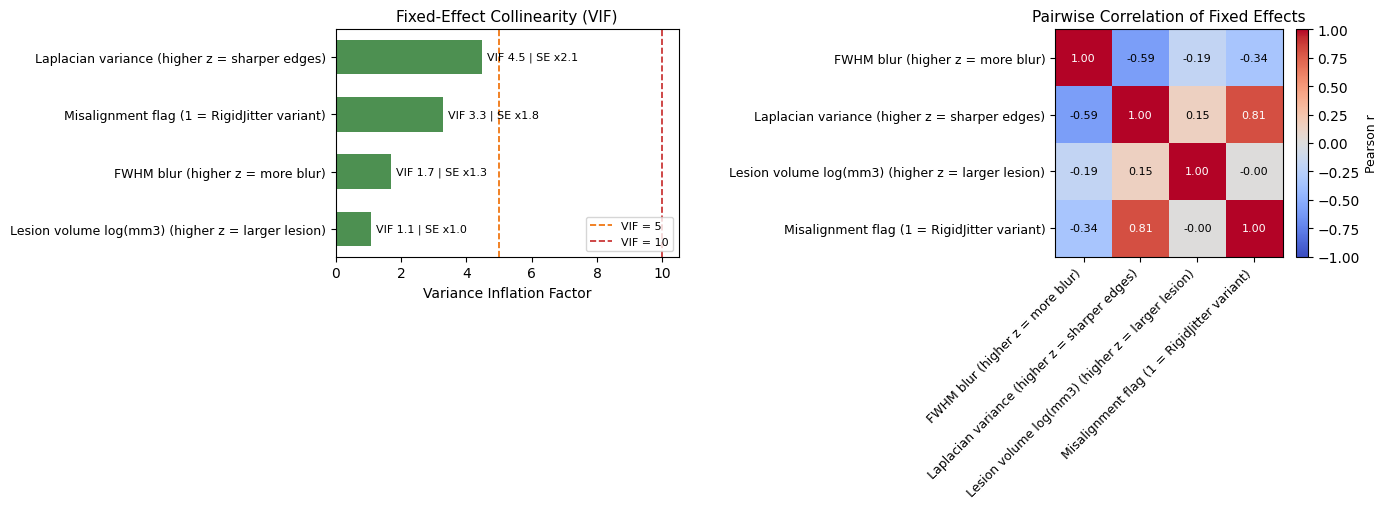

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor

RUNS_ROOT = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs")
RUN_DIRS = sorted(RUNS_ROOT.glob("*/test_eval"))
if not RUN_DIRS:
    raise FileNotFoundError(f"No test_eval directories found under {RUNS_ROOT}")
PRIMARY_RUN_DIR = RUN_DIRS[-1]

if "TERM_LABELS" not in globals():
    TERM_LABELS = {
        "z_mf_fwhm_mm": "FWHM blur\n(higher z = more blur)",
        "z_mf_lap_var": "Laplacian Variance\n(higher z = sharper edges)",
        "misalign": "Misalignment flag\n(1 = RigidJitter variant)",
        "z_log_lesion_mm3": "Lesion Volume log(mm^3)\n(higher z = larger lesion)",
    }

if "SAVE_DIR" not in globals():
    SAVE_DIR = PRIMARY_RUN_DIR

if "mixed_result" not in globals():
    def latest_csv_any(pattern: str):
        matches = sorted(path for run in RUN_DIRS for path in run.glob(pattern))
        return matches[-1] if matches else None

    variant_globs = [
        {"variant": "hires", "cohort": "hires", "role": "natural", "glob": "test_hires_metrics_with_manifest_*.csv"},
    ]
    for family, prefix in [
        ("crude", "crude"),
        ("thick_slice", "thickslices"),
        ("inplane_coarsening", "inplane"),
        ("reduced_snr", "reducedsnr"),
        ("rigid_jitter", "rigidjitter"),
    ]:
        for level in range(1, 6):
            variant_globs.append({
                "variant": f"{family}_v{level}",
                "cohort": "hires",
                "role": "degraded",
                "glob": f"test_{prefix}_v{level}_metrics_with_manifest_*.csv",
            })

    file_specs = []
    for entry in variant_globs:
        path = latest_csv_any(entry["glob"])
        if path is None:
            print(f"[warn] no CSV found for variant '{entry['variant']}' (glob: {entry['glob']}); skipping.")
            continue
        file_specs.append({
            "variant": entry["variant"],
            "cohort": entry["cohort"],
            "role": entry["role"],
            "path": str(path),
            "source_run": path.parent.parent.name,
        })

    if not file_specs:
        raise RuntimeError("No CSV files found for standalone VIF rebuild.")

    required_manifest_cols = ["key", "soft_dice", "img_path", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]
    dfs = {}
    for spec in file_specs:
        path = Path(spec["path"])
        df = pd.read_csv(path)
        missing_cols = [c for c in required_manifest_cols if c not in df.columns]
        if missing_cols:
            raise ValueError(
                f"{path.name} is missing required manifest columns: {missing_cols}. "
                "Use the *_metrics_with_manifest_*.csv file for this analysis."
            )
        if "dataset_tag" not in df.columns:
            df["dataset_tag"] = spec["cohort"]
        df["cohort"] = spec["cohort"]
        df["variant"] = spec["variant"]
        df["role"] = spec["role"]
        df["source_file"] = path.name
        df["source_run"] = spec["source_run"]
        dfs[spec["variant"]] = df

    all_df = pd.concat(dfs.values(), ignore_index=True)
    all_df["key"] = all_df["key"].astype(str)

    qm_dir = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")
    qm_csvs = sorted(qm_dir.glob("image_quality_metrics_all_variants_*.csv"))
    if not qm_csvs:
        raise FileNotFoundError(
            f"No image_quality_metrics_all_variants_*.csv found in {qm_dir}. "
            "Run ARC_ATLAS_Image_Quality_Metrics.ipynb first."
        )
    qm_path = qm_csvs[-1]
    print(f"Standalone VIF rebuild loading image-level quality metrics from: {qm_path.name}")
    qm = pd.read_csv(qm_path)
    qm_variant_map = {"test_hires": "hires"}
    for family_in, family_out in [
        ("Crude", "crude"),
        ("ThickSlices", "thick_slice"),
        ("InPlaneCoarse", "inplane_coarsening"),
        ("ReducedSNR", "reduced_snr"),
        ("RigidJitter", "rigid_jitter"),
    ]:
        for level in range(1, 6):
            qm_variant_map[f"{family_in}_v{level}"] = f"{family_out}_v{level}"
    qm["variant"] = qm["variant"].map(qm_variant_map).fillna(qm["variant"])
    qm["key"] = qm["key"].astype(str)
    qm = qm.rename(columns={
        "fwhm_mm": "mf_fwhm_mm",
        "hi_freq_energy": "mf_hi_freq_energy",
        "lap_var": "mf_lap_var",
    })[["key", "variant", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]]

    for c in ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]:
        if c in all_df.columns:
            all_df = all_df.drop(columns=[c])
    all_df = all_df.merge(qm, on=["key", "variant"], how="left")
    print("Standalone VIF rebuild QM merge NaNs:", all_df[["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]].isna().sum().to_dict())

    manifest = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/50_25_25/meta/_resolution_manifest_v2.csv")
    if manifest.exists():
        mf = pd.read_csv(manifest)[["key", "mask_ml_clean"]]
        mf["key"] = mf["key"].astype(str)
        mf["lesion_mm3"] = mf["mask_ml_clean"] * 1000
        mf = mf[["key", "lesion_mm3"]]
        if "lesion_mm3" in all_df.columns:
            all_df = all_df.drop(columns=["lesion_mm3"])
        all_df = all_df.merge(mf, on="key", how="left")
    else:
        all_df["lesion_mm3"] = np.nan
        print(f"WARNING: Resolution manifest not found at {manifest}")

    degraded_variants = [spec["variant"] for spec in file_specs if spec["role"] in ("natural", "degraded")]
    outcome = "soft_dice"
    group_col = "mf_key" if ("mf_key" in all_df.columns and all_df["mf_key"].notna().all()) else "key"
    all_quality_cols = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]
    model_quality_cols = ["mf_fwhm_mm", "mf_lap_var"]
    needed = [outcome, "cohort", "variant", "role", "dataset_tag", "key", group_col, "img_path", "lesion_mm3"] + all_quality_cols
    if "mf_bin" in all_df.columns:
        needed.append("mf_bin")
    work_df = all_df[[c for c in needed if c in all_df.columns]].copy()
    for col in [outcome] + all_quality_cols:
        work_df[col] = pd.to_numeric(work_df[col], errors="coerce")
    work_df[group_col] = work_df[group_col].astype(str)
    work_df["key"] = work_df["key"].astype(str)
    work_df["log_lesion_mm3"] = np.log1p(work_df["lesion_mm3"].clip(lower=0)) if "lesion_mm3" in work_df.columns else np.nan

    def derive_misalign_flag(df: pd.DataFrame) -> pd.Series:
        if "mf_bin" in df.columns:
            as_num = pd.to_numeric(df["mf_bin"], errors="coerce")
            uniq = set(as_num.dropna().unique().tolist())
            if uniq and uniq.issubset({0.0, 1.0}):
                return as_num.fillna(0).astype(int)
            text_hint = df["mf_bin"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
            if bool(text_hint.any()):
                return text_hint.astype(int)
        variant_hint = df["variant"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
        img_hint = df["img_path"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True) if "img_path" in df.columns else pd.Series(False, index=df.index)
        return (variant_hint | img_hint).astype(int)

    work_df["misalign"] = derive_misalign_flag(work_df)
    train_df = work_df[work_df["variant"].isin(degraded_variants)].copy()
    train_df = train_df.dropna(subset=[outcome, group_col] + model_quality_cols).copy()

    active_predictors = []
    for col in model_quality_cols:
        mu = float(train_df[col].mean())
        sd = float(train_df[col].std(ddof=0))
        if not np.isfinite(sd) or sd < 1e-12:
            sd = 1.0
        zcol = f"z_{col}"
        train_df[zcol] = (train_df[col] - mu) / sd
        if float(train_df[zcol].std(ddof=0)) > 1e-12:
            active_predictors.append(zcol)

    if train_df["log_lesion_mm3"].notna().sum() > 0:
        les_mu = float(train_df["log_lesion_mm3"].mean())
        les_sd = float(train_df["log_lesion_mm3"].std(ddof=0)) or 1.0
        train_df["z_log_lesion_mm3"] = (train_df["log_lesion_mm3"] - les_mu) / les_sd
        has_lesion_size = train_df["z_log_lesion_mm3"].notna().sum() > 0
    else:
        has_lesion_size = False

    if not active_predictors:
        print("Standalone VIF rebuild found no varying continuous quality predictors.")
    eps = 1e-6
    clipped = np.clip(train_df[outcome].astype(float).values, eps, 1 - eps)
    train_df["logit_dice"] = np.log(clipped / (1 - clipped))

    import warnings

    fixed_terms = [term for term in ["z_mf_fwhm_mm", "z_mf_lap_var"] if term in train_df.columns]
    if has_lesion_size and "z_log_lesion_mm3" not in fixed_terms:
        fixed_terms.append("z_log_lesion_mm3")
    if train_df["misalign"].nunique() > 1:
        fixed_terms.append("misalign")
    rhs = " + ".join(fixed_terms) if fixed_terms else "1"
    mixed_formula = f"logit_dice ~ {rhs}"
    print("Standalone VIF rebuild using primary run dir:", PRIMARY_RUN_DIR)
    print("Standalone VIF rebuild formula:", mixed_formula)
    print("Standalone VIF rebuild grouping column:", group_col)
    mixed_model = smf.mixedlm(
        formula=mixed_formula,
        data=train_df,
        groups=train_df[group_col],
        re_formula="1",
    )

    optimizer_attempts = []
    mixed_result = None
    for method in ["bfgs", "cg", "powell", "nm", "lbfgs"]:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                candidate = mixed_model.fit(reml=False, method=method, maxiter=2000, disp=False)
            optimizer_attempts.append({
                "method": method,
                "status": "ok",
                "converged": bool(getattr(candidate, "converged", False)),
                "n_warnings": len(caught),
            })
            if getattr(candidate, "converged", False):
                mixed_result = candidate
                mixed_result_optimizer = method
                mixed_result_warnings = [str(w.message) for w in caught]
                break
        except Exception as exc:
            optimizer_attempts.append({
                "method": method,
                "status": f"failed: {type(exc).__name__}",
                "converged": False,
                "n_warnings": np.nan,
            })
            print(f"Standalone VIF rebuild attempt with {method} failed: {exc}")

    display(pd.DataFrame(optimizer_attempts))
    if mixed_result is None:
        raise RuntimeError(
            "Standalone VIF rebuild could not fit the mixed model with any optimizer. "
            f"Tried: {', '.join(pd.DataFrame(optimizer_attempts)['method'].astype(str))}"
        )

    print(f"Standalone VIF rebuild selected optimizer: {mixed_result_optimizer}")
    if mixed_result_warnings:
        print("Warnings from selected optimizer:")
        for msg in mixed_result_warnings:
            print(f"  - {msg}")
    print(f"Standalone VIF rebuild rows: {len(train_df)}")

term_label_map = TERM_LABELS.copy()

vif_exog = pd.DataFrame(
    mixed_result.model.exog,
    columns=mixed_result.model.exog_names,
)
vif_terms = [c for c in vif_exog.columns if c != "Intercept"]

if len(vif_terms) < 2:
    print("VIF is not informative with fewer than two fixed-effect predictors.")
else:
    vif_rows = []
    for term in vif_terms:
        col_idx = vif_exog.columns.get_loc(term)
        vif_val = float(variance_inflation_factor(vif_exog.values, col_idx))
        vif_rows.append(
            {
                "term": term,
                "label": term_label_map.get(term, term).replace("\n", " "),
                "vif": vif_val,
                "sqrt_vif": float(np.sqrt(vif_val)) if np.isfinite(vif_val) and vif_val >= 0 else np.nan,
                "tolerance": float(1.0 / vif_val) if np.isfinite(vif_val) and vif_val > 0 else np.nan,
            }
        )

    vif_table = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).set_index("term")
    print("Variance Inflation Factor (VIF) diagnostics from the fitted mixed-model fixed-effect matrix:")
    print("  VIF quantifies how much predictor collinearity inflates coefficient variance.")
    print("  sqrt(VIF) is the corresponding standard-error inflation factor.")
    vif_display = vif_table.copy()
    vif_display["vif"] = vif_display["vif"].round(2)
    vif_display["sqrt_vif"] = vif_display["sqrt_vif"].round(2)
    vif_display["tolerance"] = vif_display["tolerance"].round(3)
    display(vif_display)

    predictor_corr = vif_exog[vif_terms].corr()
    abs_pairs = []
    cols = list(predictor_corr.columns)
    for i, left in enumerate(cols):
        for right in cols[i + 1:]:
            r_val = float(predictor_corr.loc[left, right])
            left_label = term_label_map.get(left, left).replace("\n", " ")
            right_label = term_label_map.get(right, right).replace("\n", " ")
            abs_pairs.append(
                {
                    "pair": f"{left_label}  vs  {right_label}",
                    "r": r_val,
                    "abs_r": abs(r_val),
                }
            )
    if abs_pairs:
        top_corr = pd.DataFrame(abs_pairs).sort_values("abs_r", ascending=False)
        print("Top pairwise correlations among fixed effects:")
        top_corr_display = top_corr[["pair", "r", "abs_r"]].head(5).copy()
        top_corr_display["r"] = top_corr_display["r"].round(3)
        top_corr_display["abs_r"] = top_corr_display["abs_r"].round(3)
        display(top_corr_display)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4.5, 0.8 * len(vif_table) + 2.0)))

    ax = axes[0]
    y = np.arange(len(vif_table))
    vif_colors = [
        "#c62828" if v >= 10 else "#ef6c00" if v >= 5 else "#2e7d32"
        for v in vif_table["vif"]
    ]
    bars = ax.barh(y, vif_table["vif"].values, color=vif_colors, alpha=0.85, height=0.6)
    ax.axvline(5, color="#ef6c00", linestyle="--", linewidth=1.2, label="VIF = 5")
    ax.axvline(10, color="#c62828", linestyle="--", linewidth=1.2, label="VIF = 10")
    ax.set_yticks(y)
    ax.set_yticklabels(vif_table["label"], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Variance Inflation Factor", fontsize=10)
    ax.set_title("Fixed-Effect Collinearity (VIF)", fontsize=11)
    ax.legend(loc="lower right", fontsize=8, frameon=True)
    x_pad = max(float(vif_table["vif"].max()) * 0.02, 0.15)
    for i, (_, row) in enumerate(vif_table.iterrows()):
        bar = bars[i]
        ax.text(
            float(row["vif"]) + x_pad,
            bar.get_y() + bar.get_height() / 2,
            f"VIF {row['vif']:.1f} | SE x{row['sqrt_vif']:.1f}",
            va="center",
            fontsize=8,
        )

    ax = axes[1]
    corr_labels = [term_label_map.get(t, t).replace("\n", " ") for t in predictor_corr.columns]
    im = ax.imshow(predictor_corr.values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(corr_labels)))
    ax.set_yticks(np.arange(len(corr_labels)))
    ax.set_xticklabels(corr_labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(corr_labels, fontsize=9)
    ax.set_title("Pairwise Correlation of Fixed Effects", fontsize=11)
    for i in range(predictor_corr.shape[0]):
        for j in range(predictor_corr.shape[1]):
            r_val = float(predictor_corr.iloc[i, j])
            ax.text(
                j,
                i,
                f"{r_val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(r_val) >= 0.65 else "black",
            )
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson r", fontsize=9)

    plt.tight_layout()
    if "SAVE_DIR" in globals():
        plt.savefig(SAVE_DIR / "fig9_vif_collinearity.png", dpi=150, bbox_inches="tight")
    plt.show()


## Figure 9: VIF Collinearity Diagnostics — Interpretation

**What the plot shows:** The left panel reports the Variance Inflation Factor for each fixed effect in the mixed model. VIF = 1 means the predictor is orthogonal to the others; values above ~5 usually indicate meaningful multicollinearity, and values above ~10 indicate severe inflation of coefficient uncertainty. The annotation `SE x...` is \(\sqrt{\mathrm{VIF}}\), which is the multiplicative inflation in that coefficient’s standard error. The right panel shows the pairwise Pearson correlation matrix for the same fixed effects.

**How to read the reduced-model check:** In v2, HFE has already been removed from the fixed effects because it was nearly redundant with Laplacian variance in the earlier model. The purpose of this figure is therefore to verify that the *remaining* fixed effects (FWHM, LapVar, misalignment, lesion size) no longer suffer from the same instability. If any remaining predictor still shows a large VIF, its coefficient should be interpreted cautiously as a conditional effect after holding the others fixed.

**Practical takeaway for this notebook:** Low-to-moderate VIF values in the reduced model support the decision to drop HFE and make the remaining coefficient signs easier to interpret mechanistically. If a predictor still has a large VIF, the next step would be to simplify further, compare one-metric-at-a-time models, or replace overlapping metrics with a shared summary such as a principal component.

**§ 22 — Figure 10: Raw vs conditional LapVar relationship.**
This section visualises the source of the LapVar sign flip. The left panel shows the **raw Dice-scale** relationship between Laplacian variance and segmentation accuracy, which matches the intuitive scatterplot question: *as LapVar goes up, does Dice usually go up too?* The right panel shows an **adjusted** relationship after removing FWHM, misalignment, lesion volume, and subject identity from both variables first (using subject fixed effects for visualisation only). That adjusted slope answers nearly the same question as the mixed-model LapVar coefficient: *for two rows that are otherwise comparable, what does extra LapVar do?*

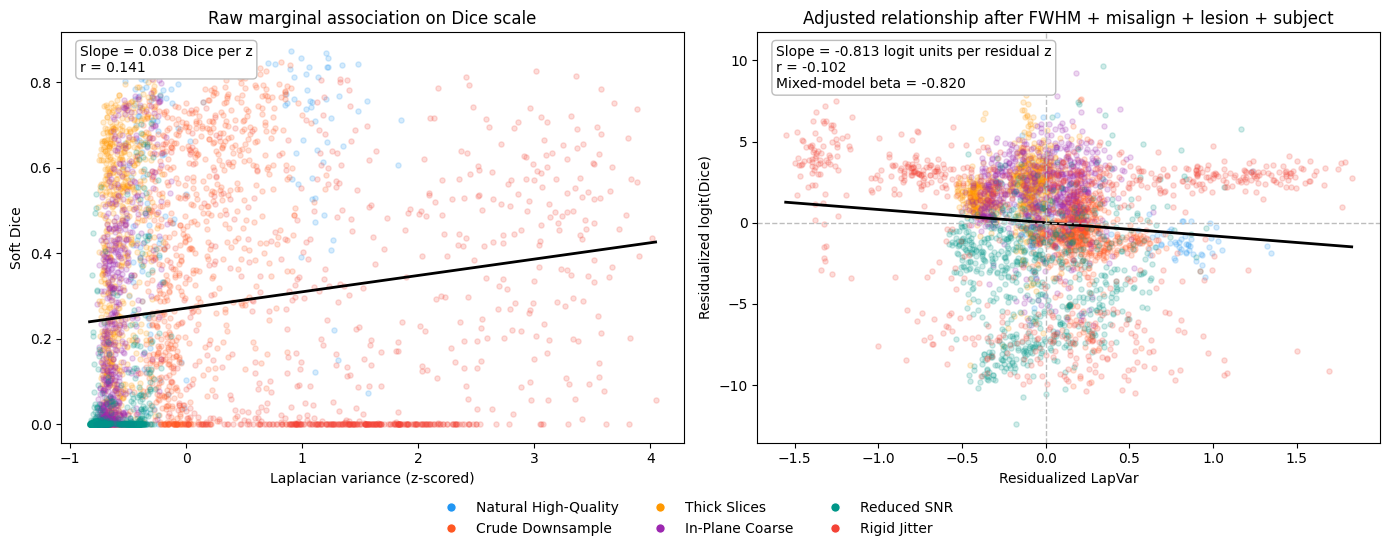


Figure 10 — LapVar marginal vs adjusted relationship:


,slope,correlation,question
view,,,
Raw Dice-scale slope,0.038,0.141,"When LapVar rises in the raw cloud, does Dice ..."
Adjusted partial slope,-0.813,-0.102,"After FWHM, misalignment, lesion volume, and s..."
Joint mixed-model coefficient,-0.820,NaN,Primary v2 model coefficient for LapVar


In [16]:
lapvar_viz_df = train_df.copy()
if "family" not in lapvar_viz_df.columns:
    lapvar_viz_df["family"] = lapvar_viz_df["variant"].map(_variant_family)

lapvar_viz_df = lapvar_viz_df.dropna(
    subset=["soft_dice", "logit_dice", "z_mf_lap_var", "z_mf_fwhm_mm", "misalign", "z_log_lesion_mm3", GROUP_COL]
).copy()

raw_fit = smf.ols("soft_dice ~ z_mf_lap_var", data=lapvar_viz_df).fit()
raw_r = float(lapvar_viz_df[["z_mf_lap_var", "soft_dice"]].corr().iloc[0, 1])

resid_y_model = smf.ols(
    f"logit_dice ~ z_mf_fwhm_mm + misalign + z_log_lesion_mm3 + C({GROUP_COL})",
    data=lapvar_viz_df,
).fit()
resid_x_model = smf.ols(
    f"z_mf_lap_var ~ z_mf_fwhm_mm + misalign + z_log_lesion_mm3 + C({GROUP_COL})",
    data=lapvar_viz_df,
).fit()

partial_df = pd.DataFrame({
    "resid_y": resid_y_model.resid,
    "resid_x": resid_x_model.resid,
    "family": lapvar_viz_df["family"].values,
})
partial_fit = smf.ols("resid_y ~ resid_x", data=partial_df).fit()
partial_r = float(partial_df[["resid_x", "resid_y"]].corr().iloc[0, 1])

family_order = [
    fam for fam in ["hires", "crude", "thick_slice", "inplane_coarsening", "reduced_snr", "rigid_jitter"]
    if fam in set(lapvar_viz_df["family"].astype(str).unique())
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
for fam in family_order:
    sub = lapvar_viz_df[lapvar_viz_df["family"] == fam]
    ax.scatter(
        sub["z_mf_lap_var"],
        sub["soft_dice"],
        s=14,
        alpha=0.18,
        color=FAMILY_COLORS.get(fam, "#9e9e9e"),
        label=FAMILY_LABELS.get(fam, fam),
    )
x_grid = np.linspace(lapvar_viz_df["z_mf_lap_var"].min(), lapvar_viz_df["z_mf_lap_var"].max(), 200)
ax.plot(x_grid, raw_fit.predict(pd.DataFrame({"z_mf_lap_var": x_grid})), color="black", lw=2.0)
ax.set_xlabel("Laplacian variance (z-scored)")
ax.set_ylabel("Soft Dice")
ax.set_title("Raw marginal association on Dice scale")
ax.text(
    0.03,
    0.97,
    f"Slope = {raw_fit.params['z_mf_lap_var']:.3f} Dice per z\nr = {raw_r:.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#bdbdbd"),
)

ax = axes[1]
for fam in family_order:
    sub = partial_df[partial_df["family"] == fam]
    ax.scatter(
        sub["resid_x"],
        sub["resid_y"],
        s=14,
        alpha=0.18,
        color=FAMILY_COLORS.get(fam, "#9e9e9e"),
    )
x_grid = np.linspace(partial_df["resid_x"].min(), partial_df["resid_x"].max(), 200)
ax.plot(
    x_grid,
    partial_fit.predict(pd.DataFrame({"resid_x": x_grid})),
    color="black",
    lw=2.0,
)
ax.axhline(0, color="#bdbdbd", lw=1, linestyle="--")
ax.axvline(0, color="#bdbdbd", lw=1, linestyle="--")
ax.set_xlabel("Residualized LapVar")
ax.set_ylabel("Residualized logit(Dice)")
ax.set_title("Adjusted relationship after FWHM + misalign + lesion + subject")
ax.text(
    0.03,
    0.97,
    f"Slope = {partial_fit.params['resid_x']:.3f} logit units per residual z\nr = {partial_r:.3f}\nMixed-model beta = {mixed_result.fe_params['z_mf_lap_var']:.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#bdbdbd"),
)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=FAMILY_COLORS.get(fam, "#9e9e9e"), markersize=7, label=FAMILY_LABELS.get(fam, fam))
    for fam in family_order
]
fig.legend(handles=handles, loc="lower center", ncol=min(3, len(handles)), frameon=False)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(SAVE_DIR / "fig10_lapvar_raw_vs_adjusted.png", dpi=150, bbox_inches="tight")
plt.show()

lapvar_relationship_df = pd.DataFrame([
    {
        "view": "Raw Dice-scale slope",
        "slope": float(raw_fit.params["z_mf_lap_var"]),
        "correlation": raw_r,
        "question": "When LapVar rises in the raw cloud, does Dice usually rise too?",
    },
    {
        "view": "Adjusted partial slope",
        "slope": float(partial_fit.params["resid_x"]),
        "correlation": partial_r,
        "question": "After FWHM, misalignment, lesion volume, and subject are held fixed, what does extra LapVar do?",
    },
    {
        "view": "Joint mixed-model coefficient",
        "slope": float(mixed_result.fe_params["z_mf_lap_var"]),
        "correlation": np.nan,
        "question": "Primary v2 model coefficient for LapVar",
    },
]).set_index("view")

print("\nFigure 10 — LapVar marginal vs adjusted relationship:")
display(lapvar_relationship_df.round(3))


## Figure 10: Why LapVar Can Be Positive in a Dice Scatterplot but Negative in the Joint Model

**What the plot shows:** The left panel matches the intuition you described directly: on the raw Dice scale, higher LapVar tends to come with higher Dice. The right panel is the conditional association after the other modeled structure has been removed first. The joint mixed-model coefficient lines up with the adjusted panel, not the raw Dice scatter.

**Practical interpretation:** In this dataset, LapVar behaves like a broad sharpness proxy in the raw Dice plot, so the marginal slope is positive. But once FWHM already explains the dominant blur axis, the remaining part of LapVar is no longer “cleanly sharper image”; it becomes the leftover edge-energy signal after blur, lesion size, misalignment, and subject baseline are accounted for. That leftover component trends negative, which is exactly why the joint coefficient flips sign.

**§ 23 — Figure 11: What the random effect and residual actually look like.**
On the logit-Dice scale, the fitted mixed model is additive:

`observed = fixed-effects prediction + subject random intercept + residual`

This figure makes those two leftover pieces concrete. The **random intercept** is a subject-wide vertical shift shared by all rows from the same subject. The **residual** is the row-specific leftover after both the fixed effects and that subject shift are applied.

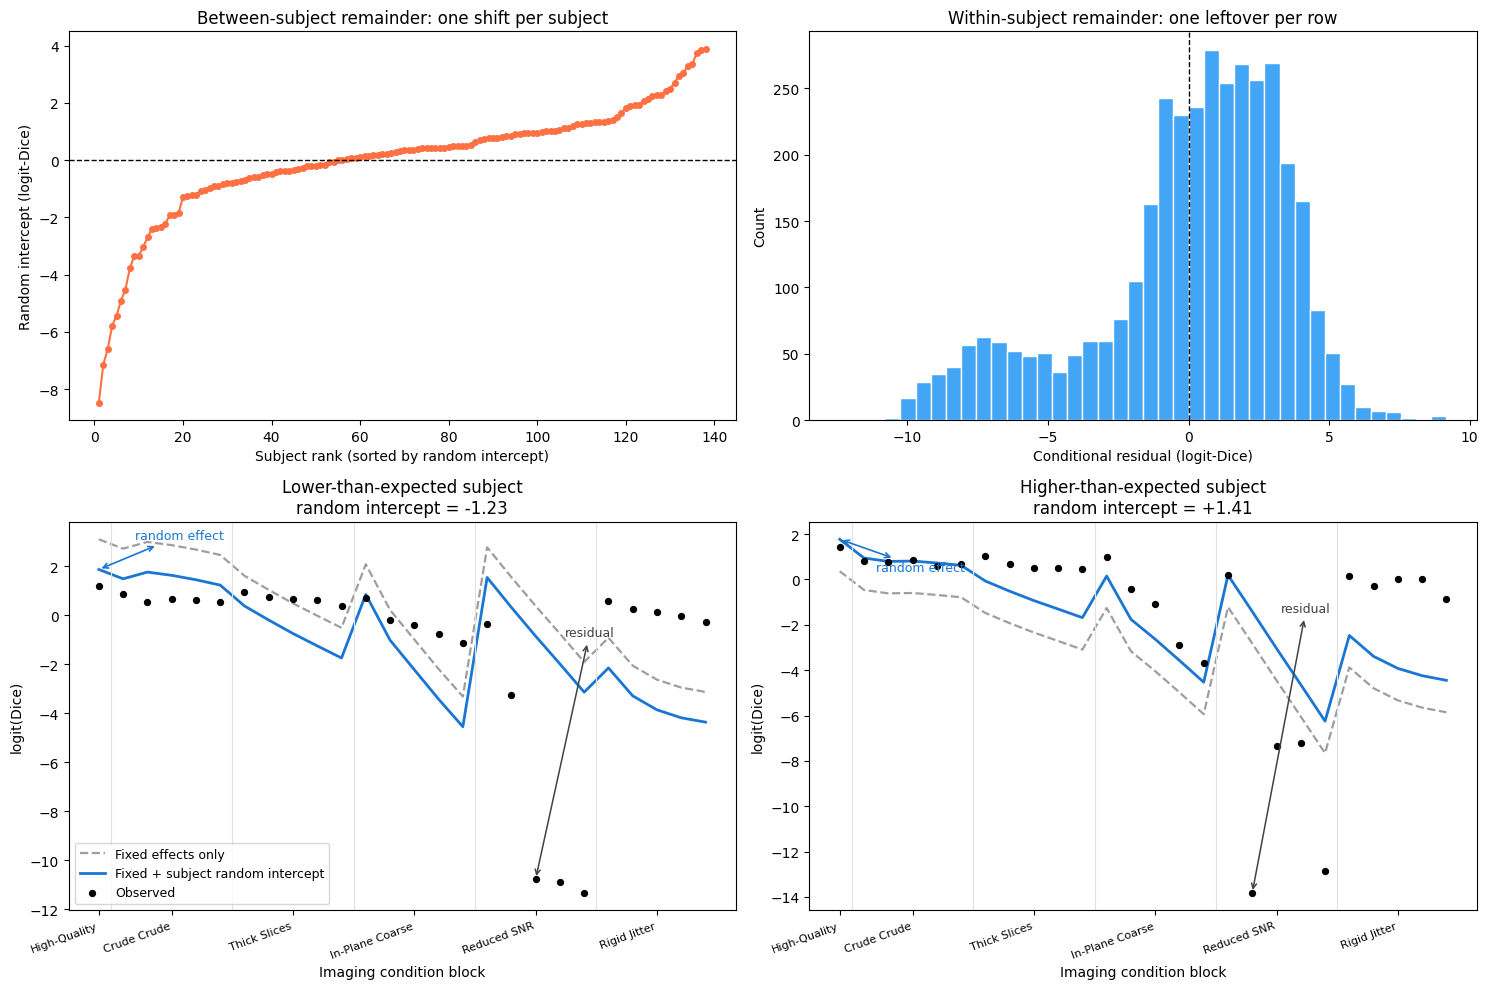


Figure 11 — Random intercept vs residual summary:


,unit,what_it_does,sd_logit
component,,,
Random subject intercept,one value per subject,Shifts that subject's whole fitted trajectory ...,2.026
Conditional residual,one value per observation,Moves an individual row away from the subject-...,3.534


In [17]:
fit_row_order = pd.Index(getattr(mixed_result.model.data, "row_labels", train_df.index))
decomp_df = train_df.loc[fit_row_order].copy()
decomp_df["family"] = decomp_df["variant"].map(_variant_family)

decomp_df["fixed_only_logit"] = mixed_result.model.exog @ mixed_result.fe_params.reindex(mixed_result.model.exog_names).to_numpy()

random_effect_map = {}
for group_id, value in mixed_result.random_effects.items():
    if hasattr(value, "iloc"):
        random_effect_map[group_id] = float(value.iloc[0])
    elif isinstance(value, dict):
        random_effect_map[group_id] = float(next(iter(value.values())))
    elif isinstance(value, (list, tuple, np.ndarray)):
        random_effect_map[group_id] = float(value[0])
    else:
        random_effect_map[group_id] = float(value)

decomp_df["random_intercept"] = decomp_df[GROUP_COL].map(random_effect_map).astype(float)
decomp_df["conditional_logit"] = decomp_df["fixed_only_logit"] + decomp_df["random_intercept"]
decomp_df["conditional_residual_logit"] = decomp_df["logit_dice"] - decomp_df["conditional_logit"]

subject_effects_df = (
    decomp_df[[GROUP_COL, "random_intercept", "z_log_lesion_mm3"]]
    .drop_duplicates()
    .sort_values("random_intercept")
    .reset_index(drop=True)
)
subject_effects_df["subject_rank"] = np.arange(1, len(subject_effects_df) + 1)

low_idx = max(0, int(round(0.15 * (len(subject_effects_df) - 1))))
high_idx = min(len(subject_effects_df) - 1, int(round(0.85 * (len(subject_effects_df) - 1))))
example_subjects = [
    ("Lower-than-expected subject", subject_effects_df.iloc[low_idx][GROUP_COL]),
    ("Higher-than-expected subject", subject_effects_df.iloc[high_idx][GROUP_COL]),
]

ordered_variants = [v for v in DEGRADED_VARIANTS if v in set(decomp_df["variant"].astype(str).unique())]
variant_tick_positions = []
variant_tick_labels = []
for idx, fam in enumerate(["hires", "crude", "thick_slice", "inplane_coarsening", "reduced_snr", "rigid_jitter"]):
    members = [i + 1 for i, v in enumerate(ordered_variants) if _variant_family(v) == fam]
    if members:
        variant_tick_positions.append(int(np.median(members)))
        variant_tick_labels.append(FAMILY_LABELS.get(fam, fam).replace("Natural ", "").replace("Downsample", "Crude"))

family_boundaries = []
last_family = None
for i, variant in enumerate(ordered_variants, start=1):
    fam = _variant_family(variant)
    if last_family is not None and fam != last_family:
        family_boundaries.append(i - 0.5)
    last_family = fam

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
ax.plot(subject_effects_df["subject_rank"], subject_effects_df["random_intercept"], color="#FF7043", lw=1.5)
ax.scatter(subject_effects_df["subject_rank"], subject_effects_df["random_intercept"], color="#FF7043", s=16)
ax.axhline(0, color="black", linestyle="--", lw=1)
ax.set_xlabel("Subject rank (sorted by random intercept)")
ax.set_ylabel("Random intercept (logit-Dice)")
ax.set_title("Between-subject remainder: one shift per subject")

ax = axes[0, 1]
ax.hist(decomp_df["conditional_residual_logit"], bins=40, color="#42A5F5", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", lw=1)
ax.set_xlabel("Conditional residual (logit-Dice)")
ax.set_ylabel("Count")
ax.set_title("Within-subject remainder: one leftover per row")

for ax, (title, subject_id) in zip(axes[1], example_subjects):
    sub = decomp_df[decomp_df[GROUP_COL] == subject_id].copy()
    sub["variant"] = pd.Categorical(sub["variant"], categories=ordered_variants, ordered=True)
    sub = sub.sort_values("variant")
    x = np.arange(1, len(sub) + 1)

    ax.plot(x, sub["fixed_only_logit"], color="#9e9e9e", lw=1.6, linestyle="--", label="Fixed effects only")
    ax.plot(x, sub["conditional_logit"], color="#1976d2", lw=2.0, label="Fixed + subject random intercept")
    ax.scatter(x, sub["logit_dice"], color="black", s=18, zorder=3, label="Observed")

    for boundary in family_boundaries:
        ax.axvline(boundary, color="#e0e0e0", lw=0.8)

    j_shift = 0
    ax.annotate(
        "random effect",
        xy=(x[j_shift], sub["conditional_logit"].iloc[j_shift]),
        xytext=(x[j_shift] + 1.5, sub["fixed_only_logit"].iloc[j_shift]),
        arrowprops=dict(arrowstyle="<->", color="#1976d2", lw=1.2),
        color="#1976d2",
        fontsize=9,
    )

    j_resid = int(np.argmax(np.abs(sub["logit_dice"].to_numpy() - sub["conditional_logit"].to_numpy())))
    ax.annotate(
        "residual",
        xy=(x[j_resid], sub["logit_dice"].iloc[j_resid]),
        xytext=(x[j_resid] + 1.2, sub["conditional_logit"].iloc[j_resid]),
        arrowprops=dict(arrowstyle="<->", color="#424242", lw=1.1),
        color="#424242",
        fontsize=9,
    )

    ax.set_xticks(variant_tick_positions)
    ax.set_xticklabels(variant_tick_labels, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("logit(Dice)")
    ax.set_title(f"{title}\nrandom intercept = {sub['random_intercept'].iloc[0]:+.2f}")

axes[1, 0].legend(loc="lower left", frameon=True, fontsize=9)
axes[1, 0].set_xlabel("Imaging condition block")
axes[1, 1].set_xlabel("Imaging condition block")

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig11_random_effect_vs_residual.png", dpi=150, bbox_inches="tight")
plt.show()

random_vs_residual_df = pd.DataFrame([
    {
        "component": "Random subject intercept",
        "unit": "one value per subject",
        "what_it_does": "Shifts that subject's whole fitted trajectory up or down together",
        "sd_logit": float(subject_effects_df["random_intercept"].std(ddof=1)),
    },
    {
        "component": "Conditional residual",
        "unit": "one value per observation",
        "what_it_does": "Moves an individual row away from the subject-specific fitted line",
        "sd_logit": float(decomp_df["conditional_residual_logit"].std(ddof=1)),
    },
]).set_index("component")

print("\nFigure 11 — Random intercept vs residual summary:")
display(random_vs_residual_df.round(3))


## Figure 11: Random Effect vs Residual — Interpretation

**What the plot shows:** The top-left panel sorts subjects by their fitted random intercept. That is the leftover subject-wide shift after the fixed effects. The top-right histogram shows the row-level residuals that remain even after each subject gets their own intercept. The bottom panels make the decomposition tangible for two example subjects.

**How to read it:**

- The gap between the dashed grey line and the solid blue line is the **random effect**: the same vertical shift applied to every row from that subject.
- The gap between the solid blue line and the black point is the **residual**: a row-specific leftover that changes from one variant to the next.
- This is why the mixed model is useful here. Repeated degradations of the same lesion are not treated as independent because they share a subject-level baseline shift before the row-level residual is computed.

**§ 24 — Model-suite recap.** Re-displays the requested continuous mixed-effects comparison without refitting anything. The original categorical degradation-family mixed models and family-by-lesion interaction models are intentionally omitted from this copy.


In [18]:
print("Requested model suite ranked by AIC:")
_rank_cols = [
    "model", "formula", "n_fixed", "n_train", "AIC", "delta_AIC", "BIC", "ICC",
    "r2_marginal", "r2_conditional", "holdout_mae", "holdout_rmse", "holdout_bias", "holdout_r", "holdout_r2",
]
display(comparison_df.sort_values("AIC")[_rank_cols].round(4))

if len(misalignment_contrast_df):
    print("\nWith/without misalignment contrasts:")
    display(misalignment_contrast_df.round(4))

print("\nHoldout calibration summary:")
display(holdout_summary_df.round(4))

print("\nMarginal and conditional R2 summary:")
display(r2_summary_df.round(4))


Requested model suite ranked by AIC:


,model,formula,n_fixed,n_train,AIC,delta_AIC,BIC,ICC,r2_marginal,r2_conditional,holdout_mae,holdout_rmse,holdout_bias,holdout_r,holdout_r2
6,FWHM x LapVar + lesion + misalign,z_mf_fwhm_mm * z_mf_lap_var + z_log_lesion_mm3...,5,3588,19202.3830,0.0000,19251.8658,0.3067,0.4461,0.6160,0.2893,0.3549,0.2024,0.4248,-0.5724
5,FWHM + LapVar + lesion + misalign,z_mf_fwhm_mm + z_mf_lap_var + z_log_lesion_mm3...,4,3588,19700.5271,498.1441,19743.8245,0.2591,0.3782,0.5393,0.2979,0.3666,0.2303,0.4448,-0.6780
2,FWHM + lesion + misalign,z_mf_fwhm_mm + z_log_lesion_mm3 + misalign,3,3588,19735.8290,533.4460,19772.9411,0.2584,0.3767,0.5377,0.3222,0.3872,0.2530,0.4181,-0.8713
4,FWHM + LapVar + lesion,z_mf_fwhm_mm + z_mf_lap_var + z_log_lesion_mm3,3,3588,19803.1955,600.8125,19840.3076,0.2484,0.3587,0.5180,0.2969,0.3660,0.2374,0.4510,-0.6727
3,FWHM + LapVar,z_mf_fwhm_mm + z_mf_lap_var,2,3588,19864.7432,662.3602,19895.6699,0.3540,0.2315,0.5035,0.3482,0.3983,0.2762,0.1352,-0.9806
1,FWHM + lesion,z_mf_fwhm_mm + z_log_lesion_mm3,2,3588,20396.6839,1194.3010,20427.6107,0.1969,0.2704,0.4141,0.4036,0.4680,0.3863,0.3958,-1.7343
0,FWHM only,z_mf_fwhm_mm,1,3588,20458.5800,1256.1970,20483.3214,0.2926,0.1416,0.3927,0.4439,0.5146,0.4332,0.1912,-2.3059



With/without misalignment contrasts:


,comparison,delta_AIC_with_minus_without,delta_BIC_with_minus_without,delta_holdout_MAE_with_minus_without,delta_marginal_R2_with_minus_without,delta_conditional_R2_with_minus_without,delta_ICC_with_minus_without
0,FWHM + lesion + misalign vs FWHM + lesion,-660.8550,-654.6696,-0.0813,0.1062,0.1237,0.0615
1,FWHM + LapVar + lesion + misalign vs FWHM + La...,-102.6685,-96.4831,0.0010,0.0195,0.0213,0.0107



Holdout calibration summary:


,holdout_mae,holdout_rmse,holdout_bias,holdout_r,holdout_r2
model,,,,,
FWHM only,0.4439,0.5146,0.4332,0.1912,-2.3059
FWHM + lesion,0.4036,0.4680,0.3863,0.3958,-1.7343
FWHM + lesion + misalign,0.3222,0.3872,0.2530,0.4181,-0.8713
FWHM + LapVar,0.3482,0.3983,0.2762,0.1352,-0.9806
FWHM + LapVar + lesion,0.2969,0.3660,0.2374,0.4510,-0.6727
FWHM + LapVar + lesion + misalign,0.2979,0.3666,0.2303,0.4448,-0.6780
FWHM x LapVar + lesion + misalign,0.2893,0.3549,0.2024,0.4248,-0.5724



Marginal and conditional R2 summary:


,r2_marginal,r2_conditional,ICC
model,,,
FWHM only,0.1416,0.3927,0.2926
FWHM + lesion,0.2704,0.4141,0.1969
FWHM + lesion + misalign,0.3767,0.5377,0.2584
FWHM + LapVar,0.2315,0.5035,0.3540
FWHM + LapVar + lesion,0.3587,0.5180,0.2484
FWHM + LapVar + lesion + misalign,0.3782,0.5393,0.2591
FWHM x LapVar + lesion + misalign,0.4461,0.6160,0.3067


## Final Model-Suite Recap — Interpretation

This final table is the paper-facing comparison of the requested continuous models. Use the AIC/BIC columns for in-sample model fit, the holdout columns for generalisation to natural low-resolution scans, ICC for the remaining subject-level variance, and marginal/conditional R² to separate fixed-effect explanation from subject random-intercept explanation.
